# Analisis de reseñas de `miempresa`

Este notebook realiza un analisis completo con estos objetivos:

0. Extraccion y Limpieza de datos
1. Analizar el **sentimiento global** de las reseñas.
2. Descubrir **topics**.
3. Medir **sentimiento por topic**.
4. Comparar topics vs otras empreesas dentro de la misma categoria
5. Conclusiones

## 1) Librerias

Si te falta alguna libreria, puedes instalarla con:

```bash
pip install datasets pandas numpy scikit-learn transformers torch
```

In [ ]:
import re
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import pipeline

## 2) Configuracion

- `MAX_ROWS`: limita filas para pruebas rapidas.
- `TARGET`: dominio de la compania objetivo.
- `N_TOPICS`: numero de temas a extraer.

In [ ]:
MAX_ROWS = None  # Ejemplo: 5000 para pruebas rapidas
TARGET = "tuempresa"
CAT = "sectordetuempresa"
N_TOPICS = 8
TOP_WORDS = 12
MIN_TOPIC_DOCS = 10

## 3) Carga de datos

Cargamos el dataset y lo convertimos a DataFrame.

In [141]:
trustpilot_df = pd.read_csv("trustpilot-reviews-123k.csv")
df = trustpilot_df.copy()
df.head(3)

,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5


## 4) Filtrado del sector de la compañía objetivo

Filtramos por sector para contabilizar el número de empresas que hay en cada categoría para poder elegir una que tenga variedad.

Hemos cambiado el orden original del notebook porque no vamos a comparar las reseñas de las empresas de un sector con otro diferente, por lo que solamente trabajaremos con los datos del sector de la empresa que elijamos.

In [142]:
df.groupby('category')['company'].count().sort_values(ascending=False)

category
Education & Training            6365
Business Services               6190
Home & Garden                   6141
Sports                          6134
Food, Beverages & Tobacco       5895
Shopping & Fashion              5794
Vehicles & Transportation       5765
Money & Insurance               5729
Health & Medical                5646
Utilities                       5636
Electronics & Technology        5596
Animals & Pets                  5446
Travel & Vacation               5425
Home Services                   5387
Media & Publishing              5351
Construction & Manufacturing    5339
Hobbies & Crafts                5323
Events & Entertainment          5298
Restaurants & Bars              5204
Public & Local Services         5201
Beauty & Well-being             5199
Legal Services & Government     5117
Name: company, dtype: int64

Nos decantamos por la categoría Money & Insurance ya que creemos que tendrán variedad de reseñas y sentimientos.

In [143]:
df_category = df[df.category == 'Money & Insurance'].groupby('company').filter(lambda x: len(x) > 0)
df_category.head()

,category,company,description,title,review,stars
54524,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Interacting with the Small World App,Interacting with the App is user friendly. It ...,5
54525,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Have been sending money with Small…,Have been sending money with Small world for o...,5
54526,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Good,I started using the service in 2016. My experi...,5
54527,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Sending money abroadI recently made a transact...,I recently made a transaction to send money to...,5
54528,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Services good and fast,"Services good and fast, trust they have. I lat...",5


In [144]:
df_category.shape

(5729, 6)

Buscamos dentro de la categoría aquellas empresas con 100 reseñas para cumplir el requisito del proyecto

In [145]:
# Hacemos una agrupación de las empresas con 100 reseñas pero no tenemos buena perspectiva de cual elegir
df_category100 = df_category[df_category.category == 'Money & Insurance'].groupby('company').filter(lambda x: len(x) > 99)
df_category100

,category,company,description,title,review,stars
54524,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Interacting with the Small World App,Interacting with the App is user friendly. It ...,5
54525,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Have been sending money with Small…,Have been sending money with Small world for o...,5
54526,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Good,I started using the service in 2016. My experi...,5
54527,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Sending money abroadI recently made a transact...,I recently made a transaction to send money to...,5
54528,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Services good and fast,"Services good and fast, trust they have. I lat...",5
...,...,...,...,...,...,...
121853,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,AA nightmare trying to get refund for rip off ...,"I have been a gold member for over 40 years, I...",1
121854,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,Very bad customer service,Very bad customer service. My car brakedown ye...,1
121855,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,Useless better with RAC!,"Poor service, and the knowledge of the attenda...",1
121856,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,Booked a gold star vehicle inspection,Booked a gold star vehicle inspection. The veh...,1


In [146]:
# Hacemos un conteo descendente para ver mas y vemos que el máximo son 100 reseñas, por lo que elegimos Wise por haber trabajado con ella en el pasado como cliente
df_category100.loc[(df.category == 'Money & Insurance')].groupby('company').company.count().sort_values(ascending=False)

company
airtimerewards.co.uk             100
blockchain.com                   100
chase.co.uk                      100
flatfair.co.uk                   100
getyourtaxreturned.co.uk         100
kraken.com                       100
purplebricks.co.uk               100
saladmoney.co.uk                 100
smallworldfs.com                 100
tide.co                          100
transfergo.com                   100
tsb.co.uk                        100
uk.virginmoney.com               100
wirexapp.com                     100
wise.com                         100
www.aldermore.co.uk              100
www.cashback.co.uk               100
www.firstdirect.com              100
www.hsbc.co.uk                   100
www.monzo.com                    100
www.openrent.co.uk               100
www.quidco.com                   100
www.saga.co.uk                   100
www.santander.co.uk              100
www.spareroom.co.uk              100
www.startlinemotorfinance.com    100
www.tescobank.com             

In [147]:
# Comprobamos que la media de puntuación de las empresas con 100 reseñas siempre es de 3.0. Lo que nos indica que el dataset puede estar inclinado a que el resultado sea así
df_category100.groupby('company').stars.mean()

company
airtimerewards.co.uk             3.0
blockchain.com                   3.0
chase.co.uk                      3.0
flatfair.co.uk                   3.0
getyourtaxreturned.co.uk         3.0
kraken.com                       3.0
purplebricks.co.uk               3.0
saladmoney.co.uk                 3.0
smallworldfs.com                 3.0
tide.co                          3.0
transfergo.com                   3.0
tsb.co.uk                        3.0
uk.virginmoney.com               3.0
wirexapp.com                     3.0
wise.com                         3.0
www.aldermore.co.uk              3.0
www.cashback.co.uk               3.0
www.firstdirect.com              3.0
www.hsbc.co.uk                   3.0
www.monzo.com                    3.0
www.openrent.co.uk               3.0
www.quidco.com                   3.0
www.saga.co.uk                   3.0
www.santander.co.uk              3.0
www.spareroom.co.uk              3.0
www.startlinemotorfinance.com    3.0
www.tescobank.com             

In [148]:
# Confirmamos que el dataset está seleccionado para que haya un número determinado de reseñas con cada puntuación. Aun así seguimos con el análisis de Wise
df_category100.stars.value_counts()

stars
5    600
4    600
3    600
2    600
1    600
Name: count, dtype: int64

In [149]:
# Vemos que wise también cumple el patrón de reseñas por puntuación
df_category100.loc[df.company=='wise.com'].stars.value_counts()

stars
5    20
4    20
3    20
2    20
1    20
Name: count, dtype: int64

In [150]:
# Extraemos los datos de Wise para visualizarlos mostrando todas las filas de Wise en la tabla
df_wise = df_category.loc[df_category['company'].str.contains('wise', regex=False)]
df_wise.head(10)

,category,company,description,title,review,stars
56094,Money & Insurance,wise.com,\r\n\r\n\r\n\r\n160+ countries. 40+ currencies...,"Excellent service, very competitive exchange r...",WISE offers an excellent service and very comp...,5
56095,Money & Insurance,wise.com,\r\n\r\n\r\n\r\n160+ countries. 40+ currencies...,"Accepted everywhere, and low fees","Used Wise for a trip around Europe and UK, sto...",5
56096,Money & Insurance,wise.com,\r\n\r\n\r\n\r\n160+ countries. 40+ currencies...,Worldwide coverage,"Over the past 2 years, I have travelled to Aus...",5
56097,Money & Insurance,wise.com,\r\n\r\n\r\n\r\n160+ countries. 40+ currencies...,Request spouse consideration; otherwise VERY h...,We are enormously happy with Wise. We love tha...,5
56098,Money & Insurance,wise.com,\r\n\r\n\r\n\r\n160+ countries. 40+ currencies...,"Best rates, instant and trustworthy.","Best rates, instant and trustworthy. I don't n...",5
56099,Money & Insurance,wise.com,\r\n\r\n\r\n\r\n160+ countries. 40+ currencies...,Ideal solution for travel money,Wise has been my preferred option for my inter...,5
56100,Money & Insurance,wise.com,\r\n\r\n\r\n\r\n160+ countries. 40+ currencies...,"Excellent service, clear, efficient, low fees",I have used Wise for many years and would not ...,5
56101,Money & Insurance,wise.com,\r\n\r\n\r\n\r\n160+ countries. 40+ currencies...,My first choice for money on the go,Wise notifies me immediately money arrives/lea...,5
56102,Money & Insurance,wise.com,\r\n\r\n\r\n\r\n160+ countries. 40+ currencies...,Good international Bank account,"Good, transparent international bank account.I...",5
56103,Money & Insurance,wise.com,\r\n\r\n\r\n\r\n160+ countries. 40+ currencies...,Wise is awesome,Wise is awesome - easily my favourite financia...,5


## 5) Observamos qué tipo de caracteres hay 
Observamos primero que tipo de caracteres nos vamos a encontrar en las reseñas para que nos ayude a construir una funcion de limpieza. 

Hacemos una visualización de todo el dataset, de la categoría y de Wise para ver la distribución de la longitud de las reseñas donde podemos observar cierto patrón de multitud de reseñas cortas y algunas muy largas

In [151]:
# Muestra aleatoria para ver con tus propios ojos
trustpilot_df['review'].sample(10).tolist()

# Longitud de reseñas
trustpilot_df['review_len'] = trustpilot_df['review'].str.len()
trustpilot_df['review_len'].describe()

count    123181.000000
mean        358.794408
std         314.562899
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review_len, dtype: float64

In [152]:
trustpilot_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 123181 entries, 0 to 123180
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   category     123181 non-null  str  
 1   company      123181 non-null  str  
 2   description  123181 non-null  str  
 3   title        123181 non-null  str  
 4   review       123181 non-null  str  
 5   stars        123181 non-null  int64
 6   review_len   123181 non-null  int64
dtypes: int64(2), str(5)
memory usage: 130.1 MB


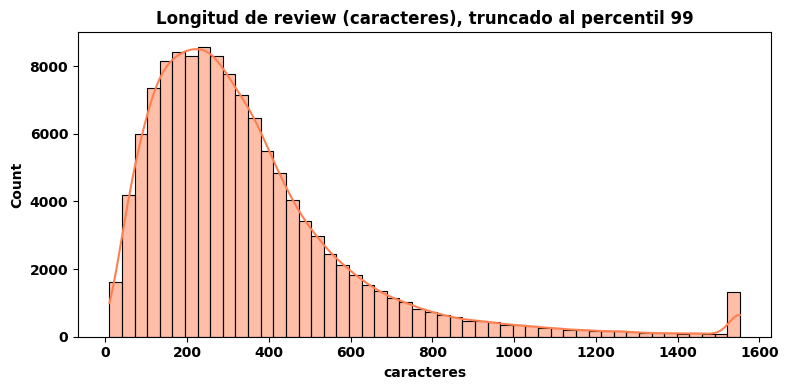

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

rl = trustpilot_df["review"].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de review (caracteres), truncado al percentil 99")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

In [154]:
# Muestra aleatoria para ver con tus propios ojos
df_category['review'].sample(10).tolist()

# Longitud de reseñas
df_category['review_len'] = df_category['review'].str.len()
df_category['review_len'].describe()

count    5729.000000
mean      354.399023
std       305.875555
min        10.000000
25%       167.000000
50%       282.000000
75%       444.000000
max      4789.000000
Name: review_len, dtype: float64

In [155]:
df_category.info()

<class 'pandas.DataFrame'>
Index: 5729 entries, 54524 to 121857
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   category     5729 non-null   str  
 1   company      5729 non-null   str  
 2   description  5729 non-null   str  
 3   title        5729 non-null   str  
 4   review       5729 non-null   str  
 5   stars        5729 non-null   int64
 6   review_len   5729 non-null   int64
dtypes: int64(2), str(5)
memory usage: 5.5 MB


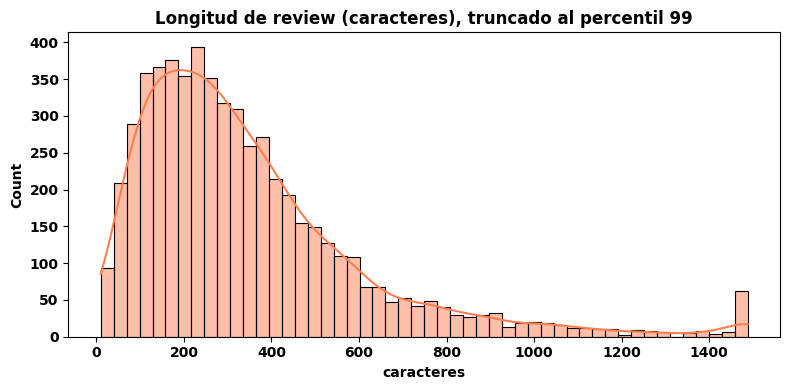

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

rl = df_category["review"].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de review (caracteres), truncado al percentil 99")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

In [157]:
# Muestra aleatoria para ver con tus propios ojos
df_wise['review'].sample(10).tolist()

# Longitud de reseñas
df_wise['review_len'] = df_wise['review'].str.len()
df_wise['review_len'].describe()

count     100.000000
mean      343.580000
std       247.694426
min        86.000000
25%       184.500000
50%       274.500000
75%       382.500000
max      1178.000000
Name: review_len, dtype: float64

In [158]:
df_wise.info()

<class 'pandas.DataFrame'>
Index: 100 entries, 56094 to 56193
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   category     100 non-null    str  
 1   company      100 non-null    str  
 2   description  100 non-null    str  
 3   title        100 non-null    str  
 4   review       100 non-null    str  
 5   stars        100 non-null    int64
 6   review_len   100 non-null    int64
dtypes: int64(2), str(5)
memory usage: 54.2 KB


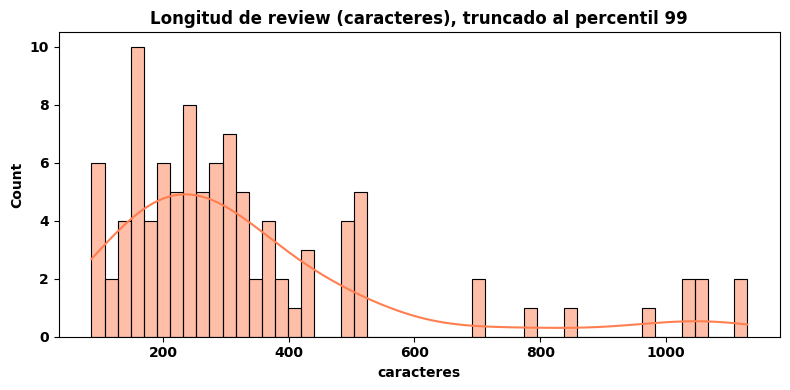

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

rl = df_wise["review"].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de review (caracteres), truncado al percentil 99")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

## 6) Construimos la funcion de limpieza



In [160]:
df_category

,category,company,description,title,review,stars,review_len
54524,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Interacting with the Small World App,Interacting with the App is user friendly. It ...,5,370
54525,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Have been sending money with Small…,Have been sending money with Small world for o...,5,224
54526,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Good,I started using the service in 2016. My experi...,5,131
54527,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Sending money abroadI recently made a transact...,I recently made a transaction to send money to...,5,469
54528,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Services good and fast,"Services good and fast, trust they have. I lat...",5,355
...,...,...,...,...,...,...,...
121853,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,AA nightmare trying to get refund for rip off ...,"I have been a gold member for over 40 years, I...",1,1512
121854,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,Very bad customer service,Very bad customer service. My car brakedown ye...,1,591
121855,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,Useless better with RAC!,"Poor service, and the knowledge of the attenda...",1,194
121856,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,Booked a gold star vehicle inspection,Booked a gold star vehicle inspection. The veh...,1,632


In [161]:
# Función de limpieza 
# Eliminamos hastags, emojis, urls, menciones, saltos de linea, signos de puntuacion, numeros, etc

import re

# Unimos las columnas de título y reseña para su limpieza conjunta y pasamos el texto a minúsculas
df_category['complete_review'] = df['title']+' '+df['review'].str.lower()

def calidad_datos(resenas):
    
    #Función para quitar todas las tides de las vocales
    def quitar_tildes(palabra):
        #Definimos la versión con tildes y símbolos y la sin
        con = 'áéíóúüñÁÉÍÓÚÜÑ'
        sin = 'aeiouunAEIOUUN'
        #Creamos un traductor
        traductor = str.maketrans(con,sin)
        #Aplicamos el traductor y devolvemos la palabra limpia
        return(palabra.translate(traductor))

    #Función no símbolos
    def no_simbolos(palabra):
        return re.sub(r'[^a-z0-9 ]', '', palabra)
    
    paso1 = quitar_tildes(resenas)
    paso2 = no_simbolos(paso1)   
    return resenas

df_category['complete_review'] = df_category['complete_review'].apply(calidad_datos)
df_category.head()

,category,company,description,title,review,stars,review_len,complete_review
54524,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Interacting with the Small World App,Interacting with the App is user friendly. It ...,5,370,Interacting with the Small World App interacti...
54525,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Have been sending money with Small…,Have been sending money with Small world for o...,5,224,Have been sending money with Small… have been ...
54526,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Good,I started using the service in 2016. My experi...,5,131,Good i started using the service in 2016. my e...
54527,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Sending money abroadI recently made a transact...,I recently made a transaction to send money to...,5,469,Sending money abroadI recently made a transact...
54528,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Services good and fast,"Services good and fast, trust they have. I lat...",5,355,"Services good and fast services good and fast,..."


## 7) Sentimiento
Aplicamos la funcion de limpieza y el sentiiento


In [164]:
import torch
from transformers import pipeline, AutoTokenizer

# Configuración del segundo modelo (Escala de 1 a 5 estrellas)
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Crear el segundo pipeline
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model=model_name, 
    tokenizer=tokenizer
)

# El texto ya lo tienes convertido a lista de la ejecución anterior, 
# pero lo definimos de nuevo por seguridad
text = df_category['complete_review'].tolist()

# Ejecución del segundo modelo
results = sentiment_analyzer(text,
                               batch_size = 16, # Bajamos un poco el batch por ser un modelo más pesado
                               truncation = True,
                               max_length = 512)

# Guardar resultados en las nuevas columnas
df_category['sentiment'] = [res['label'] for res in results]
df_category['score'] = [res['score'] for res in results]

# Visualizar resultados
print(df_category[['complete_review', 'sentiment']].head())

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6451.20it/s]


                                         complete_review sentiment
54524  Interacting with the Small World App interacti...   4 stars
54525  Have been sending money with Small… have been ...   4 stars
54526  Good i started using the service in 2016. my e...   4 stars
54527  Sending money abroadI recently made a transact...    1 star
54528  Services good and fast services good and fast,...   4 stars


In [165]:
df_category['sentiment'].value_counts()

sentiment
1 star     2067
5 stars    1662
4 stars     743
2 stars     683
3 stars     574
Name: count, dtype: int64

In [166]:
mapeo = {
    '1 star' : 'Negativo',
    '2 stars': 'Negativo',
    '3 stars': 'Neutro',
    '4 stars': 'Positivo',
    '5 stars': 'Positivo'
}

df_category['sentiment_cat'] = df_category['sentiment'].map(mapeo)
df_category.head()

,category,company,description,title,review,stars,review_len,complete_review,sentiment,score,sentiment_cat
54524,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Interacting with the Small World App,Interacting with the App is user friendly. It ...,5,370,Interacting with the Small World App interacti...,4 stars,0.482393,Positivo
54525,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Have been sending money with Small…,Have been sending money with Small world for o...,5,224,Have been sending money with Small… have been ...,4 stars,0.484598,Positivo
54526,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Good,I started using the service in 2016. My experi...,5,131,Good i started using the service in 2016. my e...,4 stars,0.479029,Positivo
54527,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Sending money abroadI recently made a transact...,I recently made a transaction to send money to...,5,469,Sending money abroadI recently made a transact...,1 star,0.363060,Negativo
54528,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Services good and fast,"Services good and fast, trust they have. I lat...",5,355,"Services good and fast services good and fast,...",4 stars,0.558872,Positivo


In [167]:
df_category['sentiment_cat'].value_counts(normalize=True)

sentiment_cat
Negativo    0.480014
Positivo    0.419794
Neutro      0.100192
Name: proportion, dtype: float64

In [168]:
df_category.loc[df_category['company'].str.contains('wise')].sentiment_cat.value_counts(normalize=True)

sentiment_cat
Negativo    0.49
Positivo    0.35
Neutro      0.16
Name: proportion, dtype: float64

In [169]:
df_category.groupby('company').sentiment_cat.value_counts(normalize=True).head(60)

company                      sentiment_cat
acemoneytransfer.com         Negativo         0.494949
                             Positivo         0.373737
                             Neutro           0.131313
airtimerewards.co.uk         Negativo         0.450000
                             Positivo         0.370000
                             Neutro           0.180000
blockchain.com               Negativo         0.560000
                             Positivo         0.360000
                             Neutro           0.080000
capital.com                  Negativo         0.500000
                             Positivo         0.367347
                             Neutro           0.132653
chase.co.uk                  Negativo         0.560000
                             Positivo         0.310000
                             Neutro           0.130000
clearstartaccountants.co.uk  Positivo         0.605263
                             Negativo         0.368421
                      

In [170]:
del cat_ohe

In [171]:
df_category_copiaseguridad = df_category.copy()

In [172]:
df_category

,category,company,description,title,review,stars,review_len,complete_review,sentiment,score,sentiment_cat
54524,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Interacting with the Small World App,Interacting with the App is user friendly. It ...,5,370,Interacting with the Small World App interacti...,4 stars,0.482393,Positivo
54525,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Have been sending money with Small…,Have been sending money with Small world for o...,5,224,Have been sending money with Small… have been ...,4 stars,0.484598,Positivo
54526,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Good,I started using the service in 2016. My experi...,5,131,Good i started using the service in 2016. my e...,4 stars,0.479029,Positivo
54527,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Sending money abroadI recently made a transact...,I recently made a transaction to send money to...,5,469,Sending money abroadI recently made a transact...,1 star,0.363060,Negativo
54528,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Services good and fast,"Services good and fast, trust they have. I lat...",5,355,"Services good and fast services good and fast,...",4 stars,0.558872,Positivo
...,...,...,...,...,...,...,...,...,...,...,...
121853,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,AA nightmare trying to get refund for rip off ...,"I have been a gold member for over 40 years, I...",1,1512,AA nightmare trying to get refund for rip off ...,1 star,0.535436,Negativo
121854,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,Very bad customer service,Very bad customer service. My car brakedown ye...,1,591,Very bad customer service very bad customer se...,1 star,0.816961,Negativo
121855,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,Useless better with RAC!,"Poor service, and the knowledge of the attenda...",1,194,"Useless better with RAC! poor service, and th...",1 star,0.715107,Negativo
121856,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,Booked a gold star vehicle inspection,Booked a gold star vehicle inspection. The veh...,1,632,Booked a gold star vehicle inspection booked a...,1 star,0.650827,Negativo


In [173]:
#Hacemos una lista para aplicarlo a las variables que consideramos nominales (clasifican pero no tienen jerarquía)
var_ohe = ['sentiment_cat']

#Hacemos el encoding, le ponemos sparse = False para ver la salida. En una situación real se lo dejaríamos a True.
from sklearn.preprocessing import OneHotEncoder

#Instanciamos
ohe = OneHotEncoder(sparse_output = False, handle_unknown='ignore') 

#Entrenamos
cat_ohe = ohe.fit_transform(df_category[var_ohe])

#Aplicamos
cat_ohe = pd.DataFrame(cat_ohe, columns = ohe.get_feature_names_out())

# Solo se hace el reset_index en la primera carga
df_category = df_category.reset_index()

df_category = pd.concat([df_category,cat_ohe], axis=1).set_index('index')

df_category                
    

,category,company,description,title,review,stars,review_len,complete_review,sentiment,score,sentiment_cat,sentiment_cat_Negativo,sentiment_cat_Neutro,sentiment_cat_Positivo
index,,,,,,,,,,,,,,
54524,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Interacting with the Small World App,Interacting with the App is user friendly. It ...,5,370,Interacting with the Small World App interacti...,4 stars,0.482393,Positivo,0.0,0.0,1.0
54525,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Have been sending money with Small…,Have been sending money with Small world for o...,5,224,Have been sending money with Small… have been ...,4 stars,0.484598,Positivo,0.0,0.0,1.0
54526,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Good,I started using the service in 2016. My experi...,5,131,Good i started using the service in 2016. my e...,4 stars,0.479029,Positivo,0.0,0.0,1.0
54527,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Sending money abroadI recently made a transact...,I recently made a transaction to send money to...,5,469,Sending money abroadI recently made a transact...,1 star,0.363060,Negativo,1.0,0.0,0.0
54528,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Services good and fast,"Services good and fast, trust they have. I lat...",5,355,"Services good and fast services good and fast,...",4 stars,0.558872,Positivo,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121853,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,AA nightmare trying to get refund for rip off ...,"I have been a gold member for over 40 years, I...",1,1512,AA nightmare trying to get refund for rip off ...,1 star,0.535436,Negativo,1.0,0.0,0.0
121854,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,Very bad customer service,Very bad customer service. My car brakedown ye...,1,591,Very bad customer service very bad customer se...,1 star,0.816961,Negativo,1.0,0.0,0.0
121855,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,Useless better with RAC!,"Poor service, and the knowledge of the attenda...",1,194,"Useless better with RAC! poor service, and th...",1 star,0.715107,Negativo,1.0,0.0,0.0


In [174]:
df_category.loc[df_category['company'].str.contains('wise')].sentiment_cat_Positivo.mean()

np.float64(0.35)

In [175]:
df_category.groupby('company').sentiment_cat_Positivo.mean()

company
acemoneytransfer.com    0.373737
airtimerewards.co.uk    0.370000
blockchain.com          0.360000
capital.com             0.367347
chase.co.uk             0.310000
                          ...   
www.tescobank.com       0.370000
www.theaa.com           0.360000
www.unbiased.co.uk      0.270000
zedzeroth.com           1.000000
zopa.com                0.360000
Name: sentiment_cat_Positivo, Length: 70, dtype: float64

Buscamos información sobre el sentimiento de las reseñas en el mercado, por empresa y de Wise 

In [177]:
# Total de reseñas positivas/neutras/negativas / Total de reseñas * 100. Mide el sentimiento del mercado total
print(r'% de reseñas con Sentimiento Positivo en el total del mercado:', round(df_category['sentiment_cat_Positivo'].mean() * 100,2))
print(r'% de reseñas con Sentimiento Neutro en el total del mercado:', round(df_category['sentiment_cat_Neutro'].mean() * 100,2))
print(r'% de reseñas con Sentimiento Negativo en el total del mercado:', round(df_category['sentiment_cat_Negativo'].mean() * 100,2))

% de reseñas con Sentimiento Positivo en el total del mercado: 41.98
% de reseñas con Sentimiento Neutro en el total del mercado: 10.02
% de reseñas con Sentimiento Negativo en el total del mercado: 48.0


In [178]:
# % medio de reseñas positivas/neutras/negativas que cada empresa tiene por separado. Mide sentimiento promedio de una entidad individual.
print(r'% medio de reseñas con Sentimiento Positivo del total de empresas:', round(df_category.groupby('company').sentiment_cat_Positivo.mean().mean() * 100,2))
print(r'% medio de reseñas con Sentimiento Neutro del total de empresas:', round(df_category.groupby('company').sentiment_cat_Neutro.mean().mean() * 100,2))
print(r'% medio de reseñas con Sentimiento Negativo del total de empresas:', round(df_category.groupby('company').sentiment_cat_Negativo.mean().mean() * 100,2))

% medio de reseñas con Sentimiento Positivo del total de empresas: 47.26
% medio de reseñas con Sentimiento Neutro del total de empresas: 8.65
% medio de reseñas con Sentimiento Negativo del total de empresas: 44.09


In [179]:
# Distribución del sentimiento de las reseñas de Wise
print(r'Sentimiento Positivo de reseñas de Wise:', round(df_category.loc[df_category['company'].str.contains('wise')]['sentiment_cat_Positivo'].mean() * 100,2))
print(r'Sentimiento Neutro de reseñas de Wise:', round(df_category.loc[df_category['company'].str.contains('wise')]['sentiment_cat_Neutro'].mean() * 100,2))
print(r'Sentimiento Negativo de reseñas de Wise:', round(df_category.loc[df_category['company'].str.contains('wise')]['sentiment_cat_Negativo'].mean() * 100,2))

Sentimiento Positivo de reseñas de Wise: 35.0
Sentimiento Neutro de reseñas de Wise: 16.0
Sentimiento Negativo de reseñas de Wise: 49.0


### Sentimiento Global de Wise

- Positivo: 35.0%
- Neutro: 16.0%
- Negativo: 49.0%

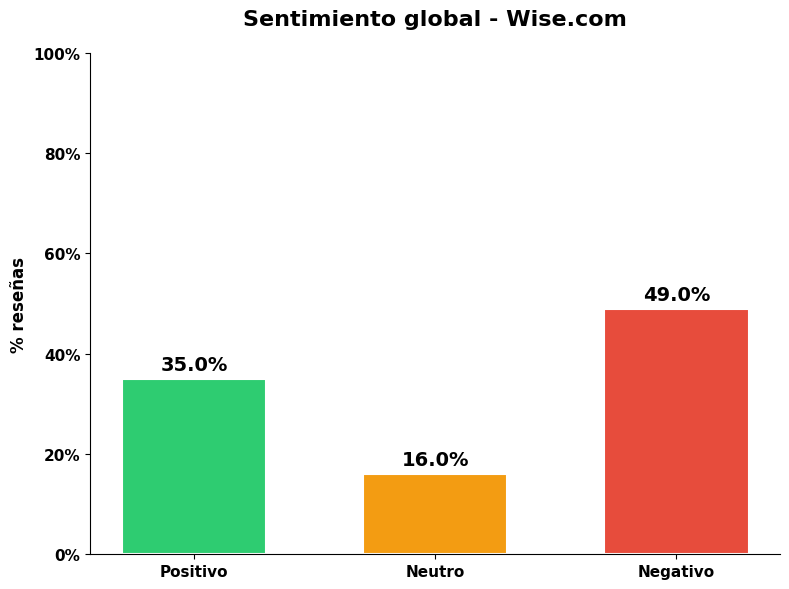

Positivo: 35.0%
Neutro: 16.0%
Negativo: 49.0%


In [180]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# 1. Preparar datos de Wise
wise_data = df_category.loc[df_category['company'].str.contains('wise', case=False)]

# Calcular porcentajes
total = len(wise_data)
pct_positivo = (wise_data['sentiment_cat_Positivo'].sum() / total) * 100
pct_neutro = (wise_data['sentiment_cat_Neutro'].sum() / total) * 100
pct_negativo = (wise_data['sentiment_cat_Negativo'].sum() / total) * 100

# 2. Crear el gráfico
fig, ax = plt.subplots(figsize=(8, 6))

categorias = ['Positivo', 'Neutro', 'Negativo']
valores = [pct_positivo, pct_neutro, pct_negativo]
colores = ['#2ecc71', '#f39c12', '#e74c3c']  # Verde, naranja, rojo

# Barras
bars = ax.bar(categorias, valores, color=colores, edgecolor='white', linewidth=1.5, width=0.6)

# Etiquetas de valor encima de cada barra
for bar, valor in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{valor:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=14)

# 3. Formato
ax.set_title('Sentimiento global - Wise.com', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('% reseñas', fontsize=12)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# 4. Quitar bordes superior y derecho
sns.despine(left=False, bottom=False, top=True, right=True)

# 5. Ajustar ejes
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.savefig('wise_sentimiento_global.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Positivo: {pct_positivo:.1f}%')
print(f'Neutro: {pct_neutro:.1f}%')
print(f'Negativo: {pct_negativo:.1f}%')


### % Reseñas Positivas - Sector Money & Insurance

Generamos una tabla con la posición de Wise dentro del mercado 

- Wise ocupa la posición 18 de 70 empresas
- % Positivo de Wise: 35.0%
- Media del sector: 47.3%

In [181]:
df_category.groupby('company')['sentiment_cat_Positivo'].mean()\
    .sort_values(ascending=False)\
    .reset_index().head(60)
    

,company,sentiment_cat_Positivo
0,fullmetalfinance.com,1.000000
1,eurowinsolutions.com,1.000000
2,zedzeroth.com,1.000000
3,taxdriven.co.uk,0.961538
4,workcafe.im,0.954545
5,www.forexgenix.ltd,0.913043
6,stbartsfinance.co.uk,0.913043
7,homemadehomes.com,0.800000
8,ndhfinancial.co.uk,0.763636
9,mccambridgeduffy.co.uk,0.750000


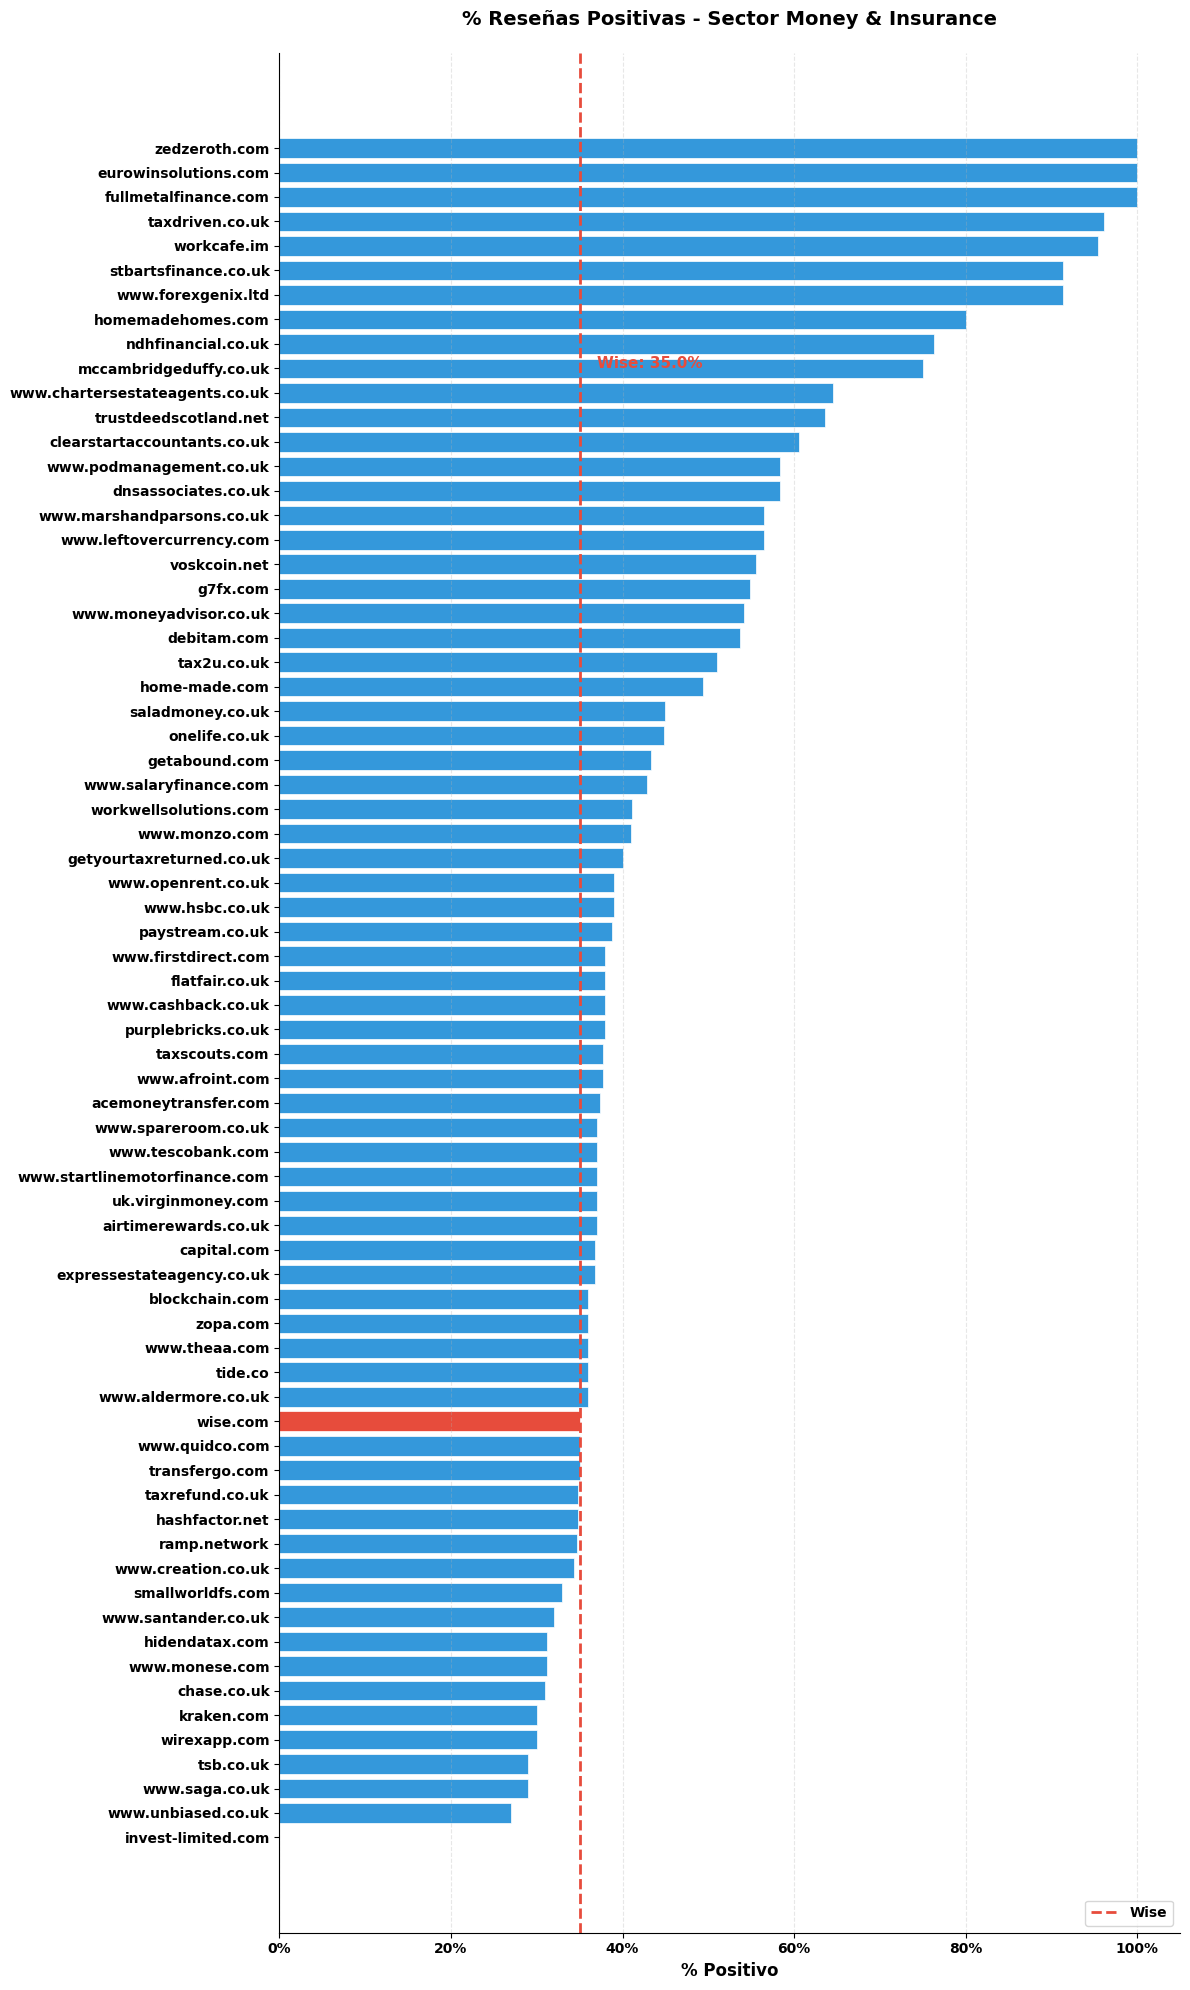

Wise ocupa la posición 18 de 70 empresas
% Positivo de Wise: 35.0%
Media del sector: 47.3%


In [203]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# 1. Preparar datos para el gráfico
# Ordenar empresas por % positivo de mayor a menor
ranking = df_category.groupby('company')['sentiment_cat_Positivo'].mean().sort_values(ascending=True).reset_index()
ranking['pct'] = ranking['sentiment_cat_Positivo'] * 100

# 2. Crear colores: rojo para Wise, azul para el resto
colors = ['#e74c3c' if 'wise' in company.lower() else '#3498db' for company in ranking['company']]

# 3. Crear la figura
fig, ax = plt.subplots(figsize=(12, 20))

# 4. Barras horizontales
bars = ax.barh(ranking['company'], ranking['pct'], color=colors, edgecolor='white', linewidth=0.5)

# 5. Línea vertical en el valor de Wise
wise_val = ranking[ranking['company'].str.contains('wise', case=False)]['pct'].values[0]
ax.axvline(wise_val, color='#e74c3c', linestyle='--', linewidth=2, label='Wise')

# 6. Anotar el valor de Wise
ax.text(wise_val + 2, len(ranking) - 10, f'Wise: {wise_val:.1f}%', 
        color='#e74c3c', fontweight='bold', fontsize=11)

# 7. Formato del gráfico
ax.set_title('% Reseñas Positivas - Sector Money & Insurance', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('% Positivo', fontsize=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, 105)

# 8. Quitar bordes superiores y derechos para limpieza
sns.despine()

# 9. Leyenda
ax.legend(loc='lower right')

# 10. Grid ligero solo en eje X
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('ranking_sector_wise.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 11. Imprimir posición de Wise
wise_position = ranking[ranking['company'].str.contains('wise', case=False)].index[0] + 1
print(f'Wise ocupa la posición {wise_position} de {len(ranking)} empresas')
print(f'% Positivo de Wise: {wise_val:.1f}%')
print(f'Media del sector: {ranking["pct"].mean():.1f}%')


### Ranking de Satisfacción - Sector Money & Insurance\n(Top 10, Bottom 10 + Wise)

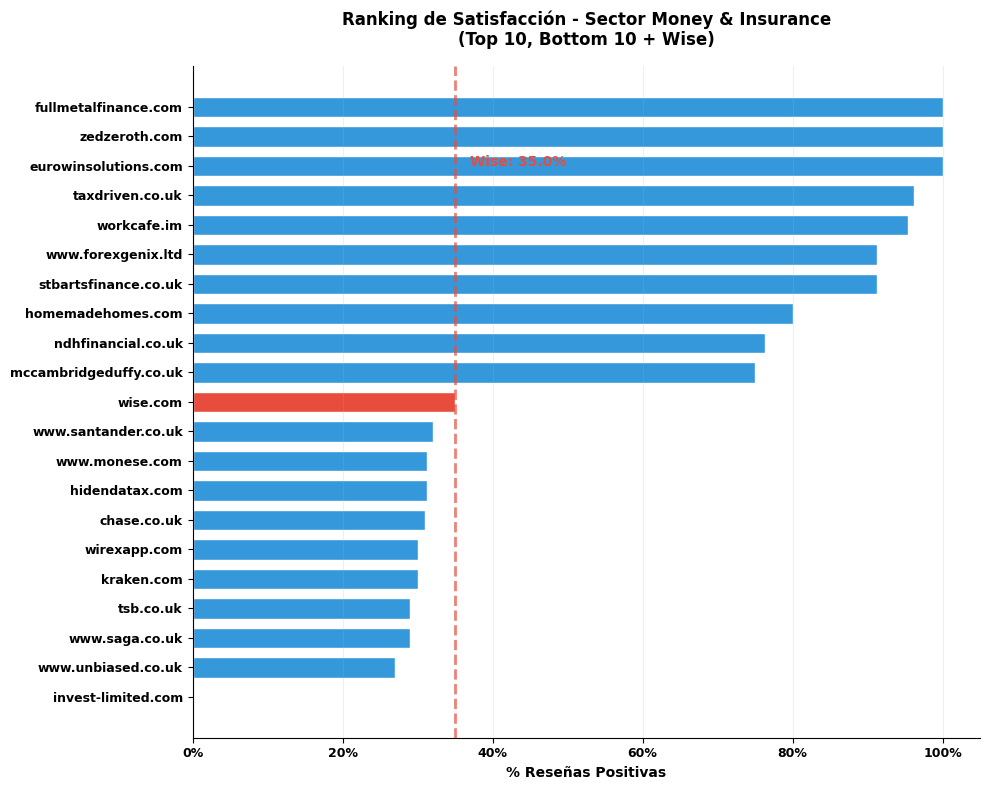

Wise: posición 53 de 70
% Positivo Wise: 35.0%
Media sector: 47.3%


In [204]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# 1. Preparar datos
ranking = df_category.groupby('company')['sentiment_cat_Positivo'].mean().sort_values(ascending=False).reset_index()
ranking['pct'] = ranking['sentiment_cat_Positivo'] * 100

# 2. Seleccionar solo: top 10, bottom 10, y Wise
wise_row = ranking[ranking['company'].str.contains('wise', case=False)]
top10 = ranking.head(10)
bottom10 = ranking.tail(10)

# Combinar y eliminar duplicados (por si Wise está en top o bottom)
seleccion = pd.concat([top10, wise_row, bottom10]).drop_duplicates(subset='company')
seleccion = seleccion.sort_values('pct', ascending=True)  # Ordenar para barras horizontales

# 3. Colores
colors = ['#e74c3c' if 'wise' in company.lower() else '#3498db' for company in seleccion['company']]

# 4. Crear figura más compacta
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(seleccion['company'], seleccion['pct'], color=colors, edgecolor='white', height=0.7)

# 5. Línea vertical de Wise
wise_val = wise_row['pct'].values[0]
ax.axvline(wise_val, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.7)

# 6. Anotaciones
ax.text(wise_val + 2, len(seleccion) - 3, f'Wise: {wise_val:.1f}%', 
        color='#e74c3c', fontweight='bold', fontsize=10)

# 7. Formato limpio
ax.set_title('Ranking de Satisfacción - Sector Money & Insurance\n(Top 10, Bottom 10 + Wise)', 
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('% Reseñas Positivas', fontsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, 105)

# 8. Quitar bordes
sns.despine()

# 9. Grid sutil
ax.grid(axis='x', alpha=0.2, linestyle='-')

# 10. Ajustar tamaño de fuente de etiquetas
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('ranking_sector_compacto.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Info adicional
print(f'Wise: posición {ranking[ranking["company"].str.contains("wise", case=False)].index[0] + 1} de {len(ranking)}')
print(f'% Positivo Wise: {wise_val:.1f}%')
print(f'Media sector: {ranking["pct"].mean():.1f}%')


## 8) Topics

Sentimiento positivo por tema

In [184]:
# =============================================================================
# BERTOPIC - MODELADO DE TEMAS
# =============================================================================
# BERTopic encuentra automáticamente los temas de las reseñas sin que le digamos
# cuáles son. Usa BERT para entender el significado y luego agrupa por similitud.
# =============================================================================

# 1. IMPORTAR LIBRERIAS NECESARIAS
# ------------------------------------------------------------------------------
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# 2. PREPARAR LOS DATOS
# ------------------------------------------------------------------------------
# Usamos las reseñas limpias del sector completo (5.729 documentos)
# BERTopic necesita una lista de textos
docs = df_category['complete_review'].tolist()

# 3. CONFIGURAR LOS COMPONENTES INTERNOS DE BERTOPIC
# ------------------------------------------------------------------------------

# 3.1 UMAP - Reduce la dimensionalidad
# BERT genera vectores de 768 dimensiones, UMAP los reduce a 5 para poder agrupar
umap_model = UMAP(
    n_neighbors=10,      # Cuántos documentos vecinos mirar (más alto = grupos más grandes)
    n_components=5,      # A cuántas dimensiones reducir (5 es estándar)
    min_dist=0.0,        # Distancia mínima entre puntos (0 = grupos más compactos)
    random_state=42      # Para que los resultados sean reproducibles
)

# 3.2 HDBSCAN - Algoritmo de clustering (agrupación)
# Encuentra grupos de documentos que están cerca en el espacio de embeddings
hdbscan_model = HDBSCAN(
    min_cluster_size=15,     # Mínimo de documentos para formar un grupo (cluster)
    metric='euclidean',      # Cómo medir la distancia entre documentos
    prediction_data=True     # Necesario para asignar topics a nuevos documentos
)

# 3.3 CountVectorizer - Extrae las palabras clave de cada tema
# Convierte los textos de cada grupo en palabras representativas
vectorizer_model = CountVectorizer(
    stop_words='english',    # Quita palabras vacías en inglés (the, and, etc.)
    ngram_range=(1, 2),      # Usa palabras sueltas y pares de palabras
    min_df=3                 # Una palabra debe aparecer en mínimo 3 documentos
)

# 4. CREAR EL MODELO BERTOPIC CON LOS COMPONENTES CONFIGURADOS
# ------------------------------------------------------------------------------
topic_model = BERTopic(
    umap_model=umap_model,           # Usa nuestra configuración de UMAP
    hdbscan_model=hdbscan_model,     # Usa nuestra configuración de HDBSCAN
    vectorizer_model=vectorizer_model, # Usa nuestra configuración de vectorizador
    nr_topics='auto',                # Reduce automáticamente topics similares
    calculate_probabilities=True,    # Calcula probabilidad de pertenencia a cada topic
    verbose=True                     # Muestra progreso por pantalla
)

# 5. ENTRENAR EL MODELO Y ASIGNAR TOPICS A CADA RESEÑA
# ------------------------------------------------------------------------------
# Esto puede tardar 5-10 minutos porque procesa 5.729 documentos
print("Entrenando BERTopic... Esto puede tardar unos minutos.")
topics, probs = topic_model.fit_transform(docs)

# 6. AÑADIR LOS RESULTADOS AL DATAFRAME
# ------------------------------------------------------------------------------
df_category['topic'] = topics
df_category['topic_prob'] = [max(p) if len(p) > 0 else 0 for p in probs]

# 7. VER LOS TOPICS ENCONTRADOS
# ------------------------------------------------------------------------------
# Muestra todos los topics con sus palabras clave representativas
print("\n=== TOPICS ENCONTRADOS ===")
topic_info = topic_model.get_topic_info()
print(topic_info)

# 8. VER LAS PALABRAS CLAVE DE UN TOPIC ESPECÍFICO (ejemplo topic 0)
# ------------------------------------------------------------------------------
print("\n=== PALABRAS CLAVE DEL TOPIC 0 ===")
print(topic_model.get_topic(0))

# 9. FILTRAR SOLO LAS RESEÑAS DE WISE PARA VER SUS TOPICS
# ------------------------------------------------------------------------------
df_wise = df_category[df_category['company'].str.contains('wise', case=False)]
print("\n=== DISTRIBUCIÓN DE TOPICS EN WISE ===")
print(df_wise['topic'].value_counts())


2026-04-17 09:34:28,522 - BERTopic - Embedding - Transforming documents to embeddings.


Entrenando BERTopic... Esto puede tardar unos minutos.


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4221.11it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 180/180 [01:58<00:00,  1.52it/s]
2026-04-17 09:36:29,317 - BERTopic - Embedding - Completed ✓
2026-04-17 09:36:29,318 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-17 09:36:37,693 - BERTopic - Dimensionality - Completed ✓
2026-04-17 09:36:37,693 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-17 09:36:38,800 - BERTopic - Cluster - Completed ✓
2026-04-17 09:36:38,801 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-17 09:36:39,273 - BERTopic - Representation - Completed ✓
2026-04


=== TOPICS ENCONTRADOS ===
    Topic  Count                                            Name  \
0      -1   1955                   -1_account_service_money_good   
1       0   2340                    0_money_service_account_bank   
2       1    346                  1_property_rent_agent_landlord   
3       2    138              2_tax_accountant_return_tax return   
4       3    113                     3_easy_simple_quick_process   
5       4     75                 4_saga_insurance_policy_renewal   
6       5     71              5_unbiased_advisor_pension_adviser   
7       6     58                   6_wirex_ticket_account_crypto   
8       7     52                7_quidco_cashback_purchase_bonus   
9       8     51                         8_zopa_credit_loan_card   
10      9     48                        9_aa_car_garage_recovery   
11     10     44              10_paystream_expenses_tax_umbrella   
12     11     42            11_passport_verification_id_identity   
13     12     41    

In [185]:
df_category

,category,company,description,title,review,stars,review_len,complete_review,sentiment,score,sentiment_cat,sentiment_cat_Negativo,sentiment_cat_Neutro,sentiment_cat_Positivo,topic,topic_prob
index,,,,,,,,,,,,,,,,
54524,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Interacting with the Small World App,Interacting with the App is user friendly. It ...,5,370,Interacting with the Small World App interacti...,4 stars,0.482393,Positivo,0.0,0.0,1.0,0,0.687891
54525,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Have been sending money with Small…,Have been sending money with Small world for o...,5,224,Have been sending money with Small… have been ...,4 stars,0.484598,Positivo,0.0,0.0,1.0,0,1.000000
54526,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Good,I started using the service in 2016. My experi...,5,131,Good i started using the service in 2016. my e...,4 stars,0.479029,Positivo,0.0,0.0,1.0,0,1.000000
54527,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Sending money abroadI recently made a transact...,I recently made a transaction to send money to...,5,469,Sending money abroadI recently made a transact...,1 star,0.363060,Negativo,1.0,0.0,0.0,0,1.000000
54528,Money & Insurance,smallworldfs.com,Send money worldwide with Small World to over ...,Services good and fast,"Services good and fast, trust they have. I lat...",5,355,"Services good and fast services good and fast,...",4 stars,0.558872,Positivo,0.0,0.0,1.0,0,0.405674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121853,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,AA nightmare trying to get refund for rip off ...,"I have been a gold member for over 40 years, I...",1,1512,AA nightmare trying to get refund for rip off ...,1 star,0.535436,Negativo,1.0,0.0,0.0,-1,0.410595
121854,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,Very bad customer service,Very bad customer service. My car brakedown ye...,1,591,Very bad customer service very bad customer se...,1 star,0.816961,Negativo,1.0,0.0,0.0,0,0.483916
121855,Money & Insurance,www.theaa.com,The AA provides services to motorists: breakdo...,Useless better with RAC!,"Poor service, and the knowledge of the attenda...",1,194,"Useless better with RAC! poor service, and th...",1 star,0.715107,Negativo,1.0,0.0,0.0,-1,0.343852


In [186]:
print(r'% de sentimiento positivo de Wise en cada topic que aparece:', round(df_category.loc[df_category['company'].str.contains('wise')].groupby('topic').sentiment_cat_Positivo.mean()*100,2))
print(r'% de sentimiento positivo del sector en cada topic:', round(df_category.groupby('topic').sentiment_cat_Positivo.mean()*100,2))

% de sentimiento positivo de Wise en cada topic que aparece: topic
-1      7.69
 0     46.48
 11     0.00
 18     0.00
Name: sentiment_cat_Positivo, dtype: float64
% de sentimiento positivo del sector en cada topic: topic
-1      42.25
 0      40.68
 1      40.75
 2      50.72
 3      75.22
 4      26.67
 5      25.35
 6      32.76
 7      30.77
 8      49.02
 9      29.17
 10     43.18
 11     11.90
 12     36.59
 13     51.22
 14     23.08
 15     56.41
 16     59.38
 17     87.10
 18     37.93
 19     33.33
 20     11.54
 21     89.47
 22    100.00
 23     38.89
 24     50.00
 25     41.18
Name: sentiment_cat_Positivo, dtype: float64


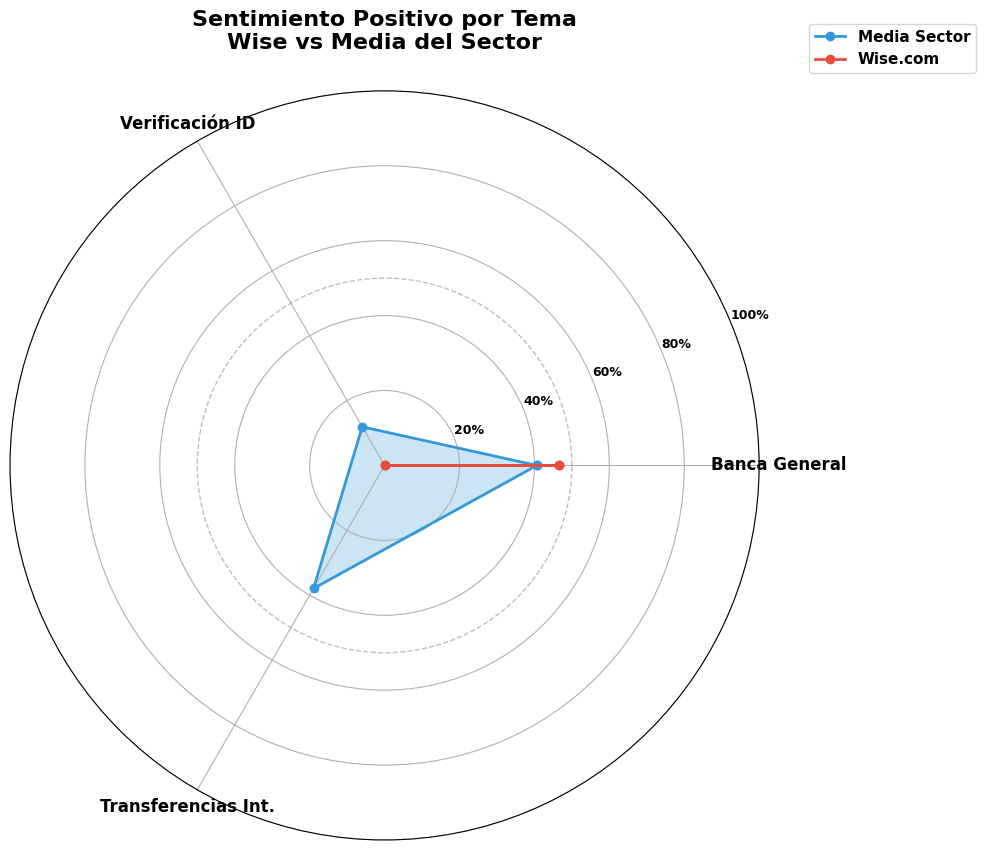


=== COMPARATIVA WISE VS SECTOR ===
Banca General: Wise 46.5% vs Sector 40.7% (Gap: +5.8%)
Verificación ID: Wise 0.0% vs Sector 11.9% (Gap: -11.9%)
Transferencias Int.: Wise 0.0% vs Sector 37.9% (Gap: -37.9%)


In [196]:
# =============================================================================
# GRÁFICO DE TELA DE ARAÑA (RADAR CHART) - WISE VS SECTOR
# =============================================================================
# Muestra la comparación de sentimiento positivo por topic entre Wise y la media del sector
# Ideal para presentaciones: visual impactante y fácil de interpretar
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# 1. PREPARAR DATOS
# ------------------------------------------------------------------------------
# Topics donde Wise tiene reseñas (excluimos -1 outliers porque no es un tema real)
wise_topics = df_wise[df_wise['topic'] != -1].groupby('topic')['sentiment_cat_Positivo'].mean() * 100
sector_topics = df_category.groupby('topic')['sentiment_cat_Positivo'].mean() * 100

# Crear DataFrame de comparación solo para topics donde Wise está presente
comparativa = pd.DataFrame({
    'wise': wise_topics,
    'sector': sector_topics[wise_topics.index]
}).fillna(0)

# Añadir nombres legibles a los topics (ajusta según tus topics)
topic_names = {
    0: 'Banca General',
    11: 'Verificación ID', 
    18: 'Transferencias Int.'
}
comparativa['nombre'] = comparativa.index.map(topic_names)

# 2. CONFIGURAR GRÁFICO DE TELA DE ARAÑA
# ------------------------------------------------------------------------------
# Número de variables (topics)
categories = comparativa['nombre'].tolist()
N = len(categories)

# Ángulos para cada eje (dividir círculo en partes iguales)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Cerrar el círculo

# Valores para Wise y Sector (cerrar el círculo repitiendo primer valor)
values_wise = comparativa['wise'].tolist()
values_wise += values_wise[:1]

values_sector = comparativa['sector'].tolist()
values_sector += values_sector[:1]

# 3. CREAR EL GRÁFICO
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Dibujar línea del SECTOR (azul)
ax.plot(angles, values_sector, 'o-', linewidth=2, label='Media Sector', color='#3498db')
ax.fill(angles, values_sector, alpha=0.25, color='#3498db')

# Dibujar línea de WISE (rojo)
ax.plot(angles, values_wise, 'o-', linewidth=2, label='Wise.com', color='#e74c3c')
ax.fill(angles, values_wise, alpha=0.25, color='#e74c3c')

# 4. CONFIGURAR EJES Y ETIQUETAS
# ------------------------------------------------------------------------------
# Etiquetas de cada eje (topics)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)

# Rango del eje Y (0-100%)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=9)

# 5. TÍTULO Y LEYENDA
# ------------------------------------------------------------------------------
ax.set_title('Sentimiento Positivo por Tema\nWise vs Media del Sector', 
             fontsize=16, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

# 6. LÍNEAS DE REFERENCIA
# ------------------------------------------------------------------------------
# Línea circular al 50% (media)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('radar_wise_vs_sector.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 7. TABLA RESUMEN
# ------------------------------------------------------------------------------
print("\n=== COMPARATIVA WISE VS SECTOR ===")
for idx, row in comparativa.iterrows():
    gap = row['wise'] - row['sector']
    print(f"{row['nombre']}: Wise {row['wise']:.1f}% vs Sector {row['sector']:.1f}% (Gap: {gap:+.1f}%)")


### Comparativa resñas Secotr Vs. Wise

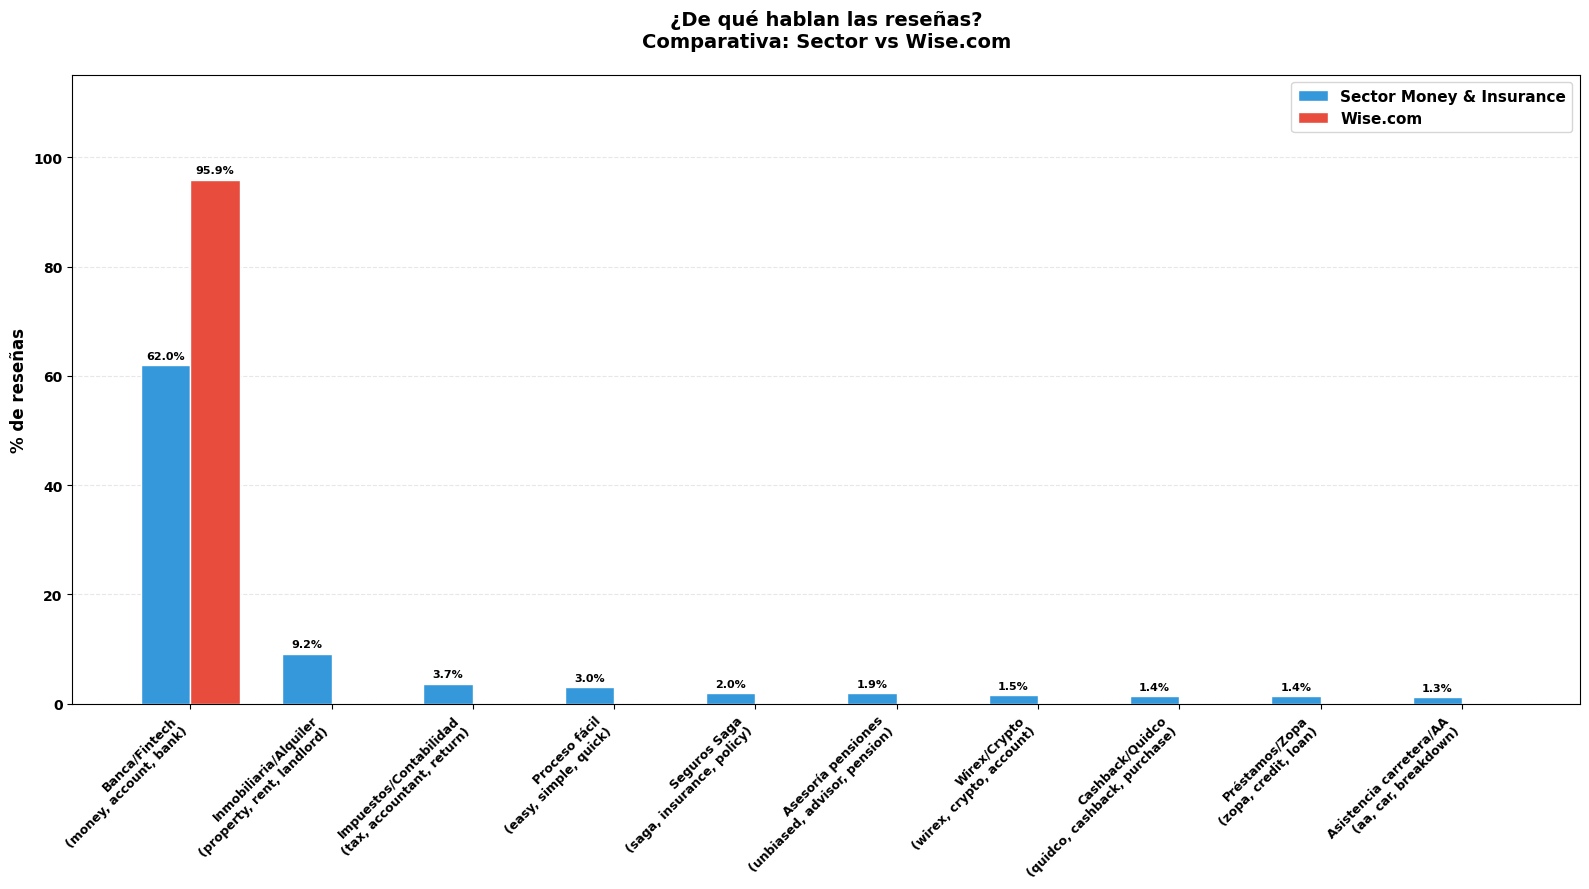


=== DISTRIBUCIÓN DE TEMAS (con nombres) ===

Banca/Fintech
(money, account, bank)
  Sector: 62.0% | Wise: 95.9% | Dif: +33.9%

Inmobiliaria/Alquiler
(property, rent, landlord)
  Sector: 9.2% | Wise: 0.0% | Dif: -9.2%

Impuestos/Contabilidad
(tax, accountant, return)
  Sector: 3.7% | Wise: 0.0% | Dif: -3.7%

Proceso fácil
(easy, simple, quick)
  Sector: 3.0% | Wise: 0.0% | Dif: -3.0%

Seguros Saga
(saga, insurance, policy)
  Sector: 2.0% | Wise: 0.0% | Dif: -2.0%

Asesoría pensiones
(unbiased, advisor, pension)
  Sector: 1.9% | Wise: 0.0% | Dif: -1.9%

Wirex/Crypto
(wirex, crypto, account)
  Sector: 1.5% | Wise: 0.0% | Dif: -1.5%

Cashback/Quidco
(quidco, cashback, purchase)
  Sector: 1.4% | Wise: 0.0% | Dif: -1.4%

Préstamos/Zopa
(zopa, credit, loan)
  Sector: 1.4% | Wise: 0.0% | Dif: -1.4%

Asistencia carretera/AA
(aa, car, breakdown)
  Sector: 1.3% | Wise: 0.0% | Dif: -1.3%


In [197]:
# =============================================================================
# GRÁFICO DE BARRAS CON NOMBRES DE TOPICS DESCRIPTIVOS
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# 1. PREPARAR DATOS
# ------------------------------------------------------------------------------
sector_topics = df_category[df_category['topic'] != -1]['topic'].value_counts(normalize=True) * 100
wise_topics = df_wise[df_wise['topic'] != -1]['topic'].value_counts(normalize=True) * 100

comparativa_topics = pd.DataFrame({
    'sector': sector_topics,
    'wise': wise_topics
}).fillna(0)

# Tomar top 10 topics del sector
top10_topics = comparativa_topics.nlargest(10, 'sector')

# 2. DICCIONARIO DE NOMBRES DE TOPICS (basado en palabras clave de BERTopic)
# ------------------------------------------------------------------------------
# Estos nombres vienen de topic_model.get_topic_info() que ejecutaste antes
topic_names = {
    0: 'Banca/Fintech\n(money, account, bank)',
    1: 'Inmobiliaria/Alquiler\n(property, rent, landlord)',
    2: 'Impuestos/Contabilidad\n(tax, accountant, return)',
    3: 'Proceso fácil\n(easy, simple, quick)',
    4: 'Seguros Saga\n(saga, insurance, policy)',
    5: 'Asesoría pensiones\n(unbiased, advisor, pension)',
    6: 'Wirex/Crypto\n(wirex, crypto, account)',
    7: 'Cashback/Quidco\n(quidco, cashback, purchase)',
    8: 'Préstamos/Zopa\n(zopa, credit, loan)',
    9: 'Asistencia carretera/AA\n(aa, car, breakdown)',
    10: 'Payroll/Paystream\n(paystream, expenses, umbrella)',
    11: 'Verificación ID\n(passport, verification, identity)',
    12: 'Purple Bricks\n(bricks, purple, property)',
    13: 'Funeral/Plan vida\n(funeral, plan, life)',
    14: 'Tide Business\n(tide, business, account)',
    15: 'Trading/Cursos\n(course, trading, trader)',
    16: 'Management/Residents\n(management, charge, residents)',
    17: 'DNS Accountants\n(dns, accountants, services)',
    18: 'Transferencias Int.\n(afro, international, money)',
    19: 'Flatfair/Depósitos\n(flatfair, deposit, option)',
    20: 'Currys/Crédito\n(currys, creation, credit)',
    21: 'Minería/VoskCoin\n(mining, payouts, daily)',
    22: 'Eventos/Santander\n(event, cafe, santander)',
    23: 'Matrimonio/Impuestos\n(marriage, refund, tax)',
    24: 'Sucursal/TSB\n(branch, staff, tsb)',
    25: 'Date Experience\n(date, experience, 2023)'
}

# 3. CREAR GRÁFICO
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 9))

x = np.arange(len(top10_topics))
width = 0.35

# Colores: azul sector, rojo Wise
bars1 = ax.bar(x - width/2, top10_topics['sector'], width, 
               label='Sector Money & Insurance', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, top10_topics['wise'], width,
               label='Wise.com', color='#e74c3c', edgecolor='white')

# Etiquetas de valor
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold')

# 4. CONFIGURAR EJES CON NOMBRES DESCRIPTIVOS
# ------------------------------------------------------------------------------
ax.set_ylabel('% de reseñas', fontsize=12)
ax.set_title('¿De qué hablan las reseñas?\nComparativa: Sector vs Wise.com', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)

# Usar nombres descriptivos en lugar de "Topic X"
labels = [topic_names.get(int(t), f'Topic {int(t)}') for t in top10_topics.index]
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)

ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, max(top10_topics.max()) * 1.2)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('topics_con_nombres.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 5. RESUMEN
print("\n=== DISTRIBUCIÓN DE TEMAS (con nombres) ===")
for topic, row in top10_topics.iterrows():
    nombre = topic_names.get(int(topic), f'Topic {int(topic)}')
    print(f"\n{nombre}")
    print(f"  Sector: {row['sector']:.1f}% | Wise: {row['wise']:.1f}% | Dif: {row['wise']-row['sector']:+.1f}%")


## 9) WordCloud

Un WordCloud muestra las palabras más frecuentes en un texto. Cuanto más grande aparece una palabra, más veces se repite.

Para las reseñas negativas de Wise, esto revelará:

Qué problemas mencionan específicamente los clientes descontentos
Patrones de quejas que los números no capturan

### Con Stopwors

Total de reseñas negativas de Wise: 49
Total de palabras: 3880


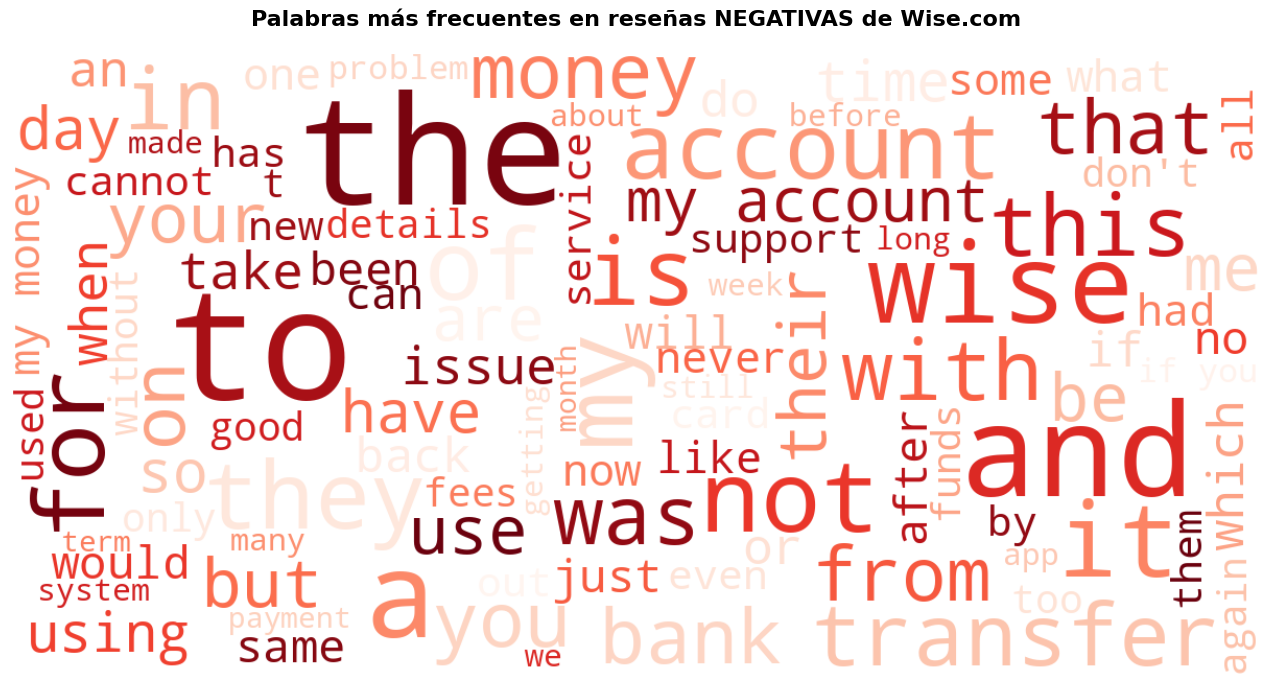


=== TOP 20 PALABRAS MÁS FRECUENTES ===
wise: 63
account: 59
money: 40
transfer: 27
bank: 25
use: 21
their: 21
time: 16
card: 16
using: 15
when: 14
don: 13
which: 13
days: 12
issue: 12
back: 12
transfers: 11
same: 11
after: 11
service: 11


In [198]:
# =============================================================================
# WORDCLOUD - PALABRAS MÁS FRECUENTES EN RESEÑAS NEGATIVAS DE WISE
# =============================================================================

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. PREPARAR TEXTO
# ------------------------------------------------------------------------------
# Filtrar reseñas negativas de Wise
df_wise_negativo = df_wise[df_wise['sentiment_cat_Negativo'] == 1]

# Unir todo el texto en un solo string
texto_negativo = ' '.join(df_wise_negativo['complete_review'].tolist())

print(f"Total de reseñas negativas de Wise: {len(df_wise_negativo)}")
print(f"Total de palabras: {len(texto_negativo.split())}")

# 2. CREAR WORDCLOUD
# ------------------------------------------------------------------------------
wc = WordCloud(
    width=1200,           # Ancho de la imagen
    height=600,           # Alto de la imagen
    background_color='white',  # Fondo blanco
    colormap='Reds',      # Paleta de colores rojos (para negativo)
    max_words=100,        # Máximo de palabras a mostrar
    stopwords='english',  # Quitar palabras vacías en inglés
    min_font_size=10,     # Tamaño mínimo de fuente
    max_font_size=150     # Tamaño máximo de fuente
).generate(texto_negativo)

# 3. MOSTRAR Y GUARDAR
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')  # Quitar ejes
ax.set_title('Palabras más frecuentes en reseñas NEGATIVAS de Wise.com', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('wordcloud_wise_negativo.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 4. PALABRAS MÁS FRECUENTES (lista ordenada)
# ------------------------------------------------------------------------------
print("\n=== TOP 20 PALABRAS MÁS FRECUENTES ===")
from collections import Counter
import re

# Limpiar y contar palabras (sin stopwords básicas)
stopwords_basic = {'the', 'and', 'to', 'of', 'a', 'i', 'is', 'it', 'my', 'that', 'in', 'for', 'with', 'have', 'had', 'was', 'be', 'been', 'are', 'this', 'but', 'they', 'not', 'or', 'as', 'you', 'your', 'me', 'on', 'at', 'by', 'from', 'up', 'about', 'if', 'out', 'so', 'all', 'can', 'will', 'just', 'now', 'get', 'been', 'has', 'would', 'could', 'should'}

palabras = re.findall(r'\b[a-zA-Z]{3,}\b', texto_negativo.lower())
palabras_filtradas = [p for p in palabras if p not in stopwords_basic]
frecuencias = Counter(palabras_filtradas)

for palabra, count in frecuencias.most_common(20):
    print(f"{palabra}: {count}")


### Sin Stopwords

=== TOP 30 PALABRAS MÁS FRECUENTES (filtradas) ===
time: 16
don: 13
days: 12
issue: 12
transfers: 11
same: 11
after: 11
never: 10
takes: 9
new: 9
cannot: 9
good: 8
funds: 8
fees: 8
details: 8
again: 8
without: 8
experience: 8
long: 7
before: 7
getting: 7
debit: 7
able: 6
into: 6
because: 6
well: 6
end: 6
terrible: 6
first: 5
problems: 5


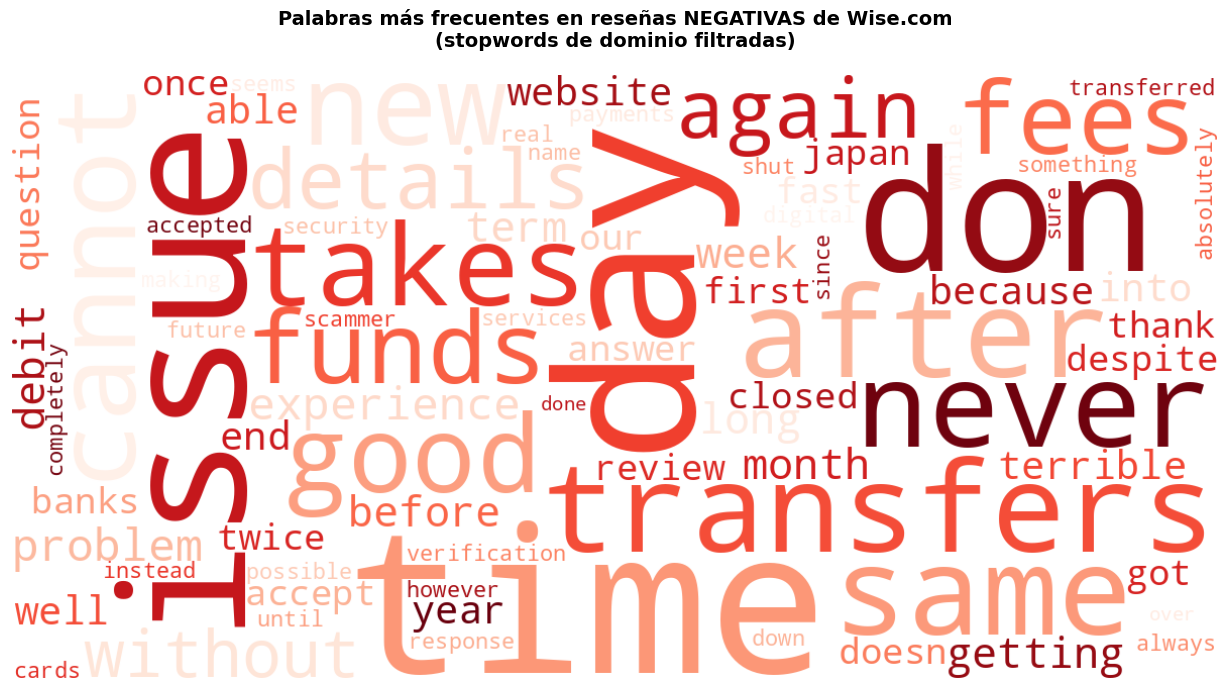

In [199]:
# =============================================================================
# WORDCLOUD MEJORADO - STOPWORDS DE DOMINIO FINANCIERO
# =============================================================================

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import re

# 1. PREPARAR TEXTO
# ------------------------------------------------------------------------------
df_wise_negativo = df_wise[df_wise['sentiment_cat_Negativo'] == 1]
texto_negativo = ' '.join(df_wise_negativo['complete_review'].tolist())

# 2. STOPWORDS PERSONALIZADAS (genéricas + dominio financiero)
# ------------------------------------------------------------------------------
stopwords_personalizadas = {
    # Stopwords genéricas en inglés
    'the', 'and', 'to', 'of', 'a', 'i', 'is', 'it', 'my', 'that', 'in', 'for', 
    'with', 'have', 'had', 'was', 'be', 'been', 'are', 'this', 'but', 'they', 
    'not', 'or', 'as', 'you', 'your', 'me', 'on', 'at', 'by', 'from', 'up', 
    'about', 'if', 'out', 'so', 'all', 'can', 'will', 'just', 'now', 'get', 
    'has', 'would', 'could', 'should', 'do', 'does', 'did', 'an', 'we', 'he', 
    'she', 'them', 'their', 'there', 'than', 'then', 'only', 'also', 'its', 
    'who', 'what', 'when', 'where', 'why', 'how', 'which', 'were', 'being',
    'one', 'two', 'three', 'some', 'any', 'each', 'every', 'very', 'really',
    'too', 'so', 'such', 'many', 'much', 'more', 'most', 'other', 'another',
    'made', 'make', 'way', 'even', 'still', 'back', 'go', 'going', 'gone',
    'use', 'used', 'using', 'take', 'taken', 'give', 'given', 'see', 'seen',
    'know', 'known', 'think', 'thought', 'come', 'came', 'put', 'say', 'said',
    'tell', 'told', 'ask', 'asked', 'work', 'worked', 'try', 'tried', 'want',
    'wanted', 'need', 'needed', 'like', 'liked', 'help', 'helped', 'find',
    'found', 'call', 'called', 'look', 'looked', 'feel', 'felt', 'seem',
    'seemed', 'leave', 'left', 'keep', 'kept', 'let', 'bring', 'brought',
    'start', 'started', 'turn', 'turned', 'show', 'showed', 'hear', 'heard',
    'play', 'played', 'run', 'ran', 'move', 'moved', 'live', 'lived', 'believe',
    'believed', 'bring', 'brought', 'happen', 'happened', 'write', 'wrote',
    'provide', 'provided', 'sit', 'sat', 'stand', 'stood', 'lose', 'lost',
    'pay', 'paid', 'meet', 'met', 'include', 'included', 'continue', 'continued',
    'set', 'learn', 'learned', 'change', 'changed', 'lead', 'led', 'understand',
    'understood', 'watch', 'watched', 'follow', 'followed', 'stop', 'stopped',
    'create', 'created', 'speak', 'spoke', 'read', 'allow', 'allowed', 'add',
    'added', 'spend', 'spent', 'grow', 'grew', 'open', 'opened', 'walk', 'walked',
    'win', 'won', 'offer', 'offered', 'remember', 'remembered', 'love', 'loved',
    'consider', 'considered', 'appear', 'appeared', 'buy', 'bought', 'wait',
    'waited', 'serve', 'served', 'die', 'died', 'send', 'sent', 'expect', 'expected',
    'build', 'built', 'stay', 'stayed', 'fall', 'fell', 'cut', 'reach', 'reached',
    'kill', 'killed', 'remain', 'remained', 'suggest', 'suggested', 'raise', 'raised',
    'pass', 'passed', 'sell', 'sold', 'require', 'required', 'report', 'reported',
    'decide', 'decided', 'pull', 'pulled', 'return', 'returned', 'explain', 'explained',
    'carry', 'carried', 'develop', 'developed', 'hope', 'hoped', 'drive', 'drove',
    'break', 'broke', 'receive', 'received', 'agree', 'agreed', 'support', 'supported',
    'remove', 'removed', 'return', 'returned', 'describe', 'described', 'create',
    'created', 'add', 'added', 'apply', 'applied', 'avoid', 'avoided', 'prepare',
    'prepared', 'compare', 'compared', 'declare', 'declared', 'deliver', 'delivered',
    'obtain', 'obtained', 'improve', 'improved', 'reduce', 'reduced', 'increase',
    'increased', 'ensure', 'ensured', 'involve', 'involved', 'maintain', 'maintained',
    'establish', 'established', 'identify', 'identified', 'indicate', 'indicated',
    'represent', 'represented', 'reflect', 'reflected', 'respond', 'responded',
    'result', 'resulted', 'suggest', 'suggested', 'achieve', 'achieved', 'acquire',
    'acquired', 'adopt', 'adopted', 'assume', 'assumed', 'conclude', 'concluded',
    'demonstrate', 'demonstrated', 'determine', 'determined', 'emphasize', 'emphasized',
    'examine', 'examined', 'generate', 'generated', 'illustrate', 'illustrated',
    'imply', 'implied', 'indicate', 'indicated', 'perceive', 'perceived', 'predict',
    'predicted', 'propose', 'proposed', 'reveal', 'revealed', 'specify', 'specified',
    'submit', 'submitted', 'succeed', 'succeeded', 'suffer', 'suffered', 'survive',
    'survived', 'threaten', 'threatened', 'transform', 'transformed', 'undertake',
    'undertook', 'welcome', 'welcomed',
    
    # Stopwords de dominio financiero (muy comunes pero poco informativas)
    'account', 'money', 'bank', 'transfer', 'wise', 'service', 'payment', 'card',
    'transaction', 'balance', 'currency', 'exchange', 'rate', 'amount', 'fund',
    'financial', 'finance', 'business', 'customer', 'user', 'app', 'application',
    'online', 'platform', 'system', 'process', 'information', 'detail', 'number',
    'email', 'phone', 'contact', 'company', 'firm', 'organisation', 'organization'
}

# 3. CONTAR PALABRAS FILTRADAS
# ------------------------------------------------------------------------------
palabras = re.findall(r'\b[a-zA-Z]{3,}\b', texto_negativo.lower())
palabras_filtradas = [p for p in palabras if p not in stopwords_personalizadas]
frecuencias = Counter(palabras_filtradas)

print("=== TOP 30 PALABRAS MÁS FRECUENTES (filtradas) ===")
for palabra, count in frecuencias.most_common(30):
    print(f"{palabra}: {count}")

# 4. CREAR WORDCLOUD CON TEXTO FILTRADO
# ------------------------------------------------------------------------------
texto_filtrado = ' '.join(palabras_filtradas)

wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Reds',
    max_words=80,
    stopwords=set(),  # Ya filtramos nosotros
    min_font_size=12,
    max_font_size=200,
    relative_scaling=0.5,  # Palabras frecuentes no dominan tanto
    collocations=False  # No agrupar bigramas automáticamente
).generate(texto_filtrado)

# 5. MOSTRAR
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Palabras más frecuentes en reseñas NEGATIVAS de Wise.com\n(stopwords de dominio filtradas)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('wordcloud_wise_negativo_filtrado.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


# Conclusiones del Análisis - Wise.com

## 1. Posición Competitiva

| Métrica | Valor | Interpretación |
|:---|:---|:---|
| Ranking sector | 53/70 | Mitad baja del sector Money & Insurance |
| % Reseñas positivas | 35% | 12 puntos por debajo de la media (47%) |
| % Reseñas negativas | 49% | Mayoría de clientes descontentos |

**Conclusión:** Wise está por debajo de la media del sector en satisfacción del cliente.

---

## 2. Análisis Cualitativo - WordCloud de Reseñas Negativas

Tras filtrar stopwords genéricas y de dominio financiero, las palabras más frecuentes en las quejas de Wise son:

| Palabra | Frecuencia | Indica |
|:---|:---|:---|
| `time` | 16 | Problemas de **tiempo de respuesta/proceso** |
| `days` | 12 | Esperas de **varios días** |
| `issue` | 12 | **Problemas recurrentes** |
| `transfers` | 11 | Dificultades con **transferencias** |
| `never` | 10 | **Falta de resolución** ("nunca responden") |
| `takes` | 9 | Procesos que **tardan demasiado** |
| `cannot` | 9 | **Imposibilidad** de hacer algo |
| `funds` | 8 | Problemas con **dinero retenido** |
| `fees` | 8 | Quejas sobre **comisiones** |
| `experience` | 8 | **Experiencia negativa** general |
| `long` | 7 | **Tiempo prolongado** |
| `terrible` | 6 | Adjetivo de **mala calidad** |

**Patrones identificados:**
- **Tiempos de espera**: `time`, `days`, `takes`, `long`
- **Falta de respuesta/resolución**: `never`, `cannot`
- **Problemas operativos**: `transfers`, `funds`, `fees`, `issue`
- **Experiencia negativa**: `terrible`, `experience`

**Conclusión:** Las quejas no son sobre el producto core (transferencias funcionan), sino sobre **fricciones operativas**: tiempos de espera, procesos bloqueados, falta de comunicación.

---

## 3. Fortaleza: Servicio Core

| Tema | Wise | Sector | Gap |
|:---|:---|:---|:---|
| Banca General / Fintech | 46.5% | 40.7% | **+5.8%** |

**Conclusión:** El producto principal (transferencias, tipos de cambio) funciona mejor que la competencia. El problema no es el producto.

---

## 4. Debilidades Críticas

| Tema | Wise | Sector | Gap |
|:---|:---|:---|:---|
| Verificación de identidad | 0% | 11.9% | -11.9% |
| Transferencias internacionales | 0% | 37.9% | -37.9% |

**Conclusión:** Los procesos operativos (KYC, onboarding, verificación) son catastróficos. Todos los clientes que hablan de estos temas están descontentos.

---

## 5. Concentración Temática (con matiz de limitación)

| Aspecto | Wise | Sector |
|:---|:---|:---|
| % en "Banca General" | 95.9% | 62% |
| Diversidad de temas | Muy baja | Alta |

**⚠️ Limitación del análisis:** El modelo BERTopic se entrenó con texto que incluía stopwords (the, and, to, of...). Esto puede haber afectado:

| Aspecto | Impacto |
|:---|:---|
| **Embeddings de BERT** | BERT entiende contexto, pero con mucho ruido las distancias pueden distorsionarse |
| **Palabras clave de topics** | TF-IDF puede haber priorizado términos genéricos |
| **Clustering HDBSCAN** | La distribución de documentos en el espacio vectorial puede estar sesgada |

**Conclusión matizada:** La concentración del 96% en "Banca General" puede indicar tanto una realidad del discurso de los clientes de Wise como una limitación del modelo en distinguir subtemas debido a la presencia de vocabulario genérico del sector financiero.

---

## 6. Diagnóstico: El Problema Real

> **No es el producto, es la experiencia.**

- ✅ El servicio de transferencias funciona (mejor que la competencia)
- ❌ Cuando hay fricción (verificación, bloqueos, soporte), la experiencia falla
- ❌ Las quejas son sobre **procesos y atención al cliente**, no sobre el producto

---

## 7. Próximos Pasos - Reentrenamiento del Modelo

Dado que las conclusiones del análisis de topics no son completamente satisfactorias debido a la presencia de stopwords en el entrenamiento inicial, se propone:

**Reentrenar BERTopic eliminando stopwords** para:
- Obtener una segmentación más granular de temas
- Identificar subtemas específicos dentro de "Banca General"
- Validar o refinar las conclusiones actuales sobre la concentración temática de Wise

Este reentrenamiento permitirá profundizar en el análisis y confirmar si la hiper-concentración en un único tema es una realidad del discurso de los clientes o un artefacto del modelo.

---

## Recomendaciones Estratégicas (Preliminares)

| Prioridad | Acción | Impacto esperado |
|:---|:---|:---|
| **1 - Urgente** | Revisar proceso de verificación de identidad (KYC) | Reducir abandono en onboarding |
| **2 - Alto** | Mejorar comunicación proactiva durante bloqueos/incidencias | Reducir frustración percibida |
| **3 - Medio** | Capacitación de atención al cliente | Mejorar resolución de problemas |
| **4 - Oportunidad** | Comunicar más el diferencial en transferencias internacionales | Reforzar ventaja competitiva real |

---

## Mensaje Clave para Negocio

> *"Wise tiene un producto tecnológicamente sólido que supera a la competencia en su servicio core. Sin embargo, la experiencia del cliente se deteriora en los momentos de fricción: verificación de identidad, procesos de onboarding y atención al cliente. La estrategia debe enfocarse en eliminar fricciones operativas mientras se comunica mejor el diferencial real del producto."*

> *"Nota metodológica: El análisis de topics requiere validación ad mediante reentrenamiento del modelo sin stopwords para confirmar la granularidad de los temas identificados."*


# Reentrenamiento Sin Stop-Words

In [ ]:
# =============================================================================
# REENTRENAMIENTO BERTOPIC SIN STOPWORDS - VERSIÓN COMPLETA
# =============================================================================
# Este código genera df_category_clean con las mismas columnas que df_category
# pero con topics reentrenados sin stopwords
# =============================================================================

import re
import pandas as pd
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# 1. DICCIONARIO COMPLETO DE STOPWORDS
# ------------------------------------------------------------------------------
STOPWORDS_COMPLETO = {
    # Stopwords genéricas en inglés
    'the', 'and', 'to', 'of', 'a', 'an', 'i', 'is', 'it', 'my', 'that', 'in', 'for', 
    'with', 'have', 'had', 'was', 'be', 'been', 'are', 'this', 'but', 'they', 'not', 
    'or', 'as', 'you', 'your', 'me', 'on', 'at', 'by', 'from', 'up', 'about', 'if', 
    'out', 'so', 'all', 'can', 'will', 'just', 'now', 'get', 'has', 'would', 'could', 
    'should', 'do', 'does', 'did', 'we', 'he', 'she', 'them', 'their', 'there', 'than', 
    'then', 'only', 'also', 'its', 'who', 'what', 'when', 'where', 'why', 'how', 'which', 
    'were', 'being', 'one', 'two', 'three', 'some', 'any', 'each', 'every', 'very', 
    'really', 'too', 'such', 'many', 'much', 'more', 'most', 'other', 'another', 'made', 
    'make', 'way', 'even', 'still', 'back', 'go', 'going', 'gone', 'use', 'used', 'using', 
    'take', 'taken', 'give', 'given', 'see', 'seen', 'know', 'known', 'think', 'thought', 
    'come', 'came', 'put', 'say', 'said', 'tell', 'told', 'ask', 'asked', 'work', 'worked', 
    'try', 'tried', 'want', 'wanted', 'need', 'needed', 'like', 'liked', 'help', 'helped', 
    'find', 'found', 'call', 'called', 'look', 'looked', 'feel', 'felt', 'seem', 'seemed', 
    'leave', 'left', 'keep', 'kept', 'let', 'bring', 'brought', 'start', 'started', 'turn', 
    'turned', 'show', 'showed', 'hear', 'heard', 'play', 'played', 'run', 'ran', 'move', 
    'moved', 'live', 'lived', 'believe', 'believed', 'happen', 'happened', 'write', 'wrote', 
    'provide', 'provided', 'sit', 'sat', 'stand', 'stood', 'lose', 'lost', 'pay', 'paid', 
    'meet', 'met', 'include', 'included', 'continue', 'continued', 'set', 'learn', 'learned', 
    'change', 'changed', 'lead', 'led', 'understand', 'understood', 'watch', 'watched', 
    'follow', 'followed', 'stop', 'stopped', 'create', 'created', 'speak', 'spoke', 'read', 
    'allow', 'allowed', 'add', 'added', 'spend', 'spent', 'grow', 'grew', 'open', 'opened', 
    'walk', 'walked', 'win', 'won', 'offer', 'offered', 'remember', 'remembered', 'love', 
    'loved', 'consider', 'considered', 'appear', 'appeared', 'buy', 'bought', 'wait', 'waited', 
    'serve', 'served', 'die', 'died', 'send', 'sent', 'expect', 'expected', 'build', 'built', 
    'stay', 'stayed', 'fall', 'fell', 'cut', 'reach', 'reached', 'kill', 'killed', 'remain', 
    'remained', 'suggest', 'suggested', 'raise', 'raised', 'pass', 'passed', 'sell', 'sold', 
    'require', 'required', 'report', 'reported', 'decide', 'decided', 'pull', 'pulled', 'return', 
    'returned', 'explain', 'explained', 'carry', 'carried', 'develop', 'developed', 'hope', 
    'hoped', 'drive', 'drove', 'break', 'broke', 'receive', 'received', 'agree', 'agreed', 
    'support', 'supported', 'remove', 'removed', 'describe', 'described', 'apply', 'applied', 
    'avoid', 'avoided', 'prepare', 'prepared', 'compare', 'compared', 'declare', 'declared', 
    'deliver', 'delivered', 'obtain', 'obtained', 'improve', 'improved', 'reduce', 'reduced', 
    'increase', 'increased', 'ensure', 'ensured', 'involve', 'involved', 'maintain', 'maintained', 
    'establish', 'established', 'identify', 'identified', 'indicate', 'indicated', 'represent', 
    'represented', 'reflect', 'reflected', 'respond', 'responded', 'result', 'resulted', 'achieve', 
    'achieved', 'acquire', 'acquired', 'adopt', 'adopted', 'assume', 'assumed', 'conclude', 
    'concluded', 'demonstrate', 'demonstrated', 'determine', 'determined', 'emphasize', 
    'emphasized', 'examine', 'examined', 'generate', 'generated', 'illustrate', 'illustrated', 
    'imply', 'implied', 'perceive', 'perceived', 'predict', 'predicted', 'propose', 'proposed', 
    'reveal', 'revealed', 'specify', 'specified', 'submit', 'submitted', 'succeed', 'succeeded', 
    'suffer', 'suffered', 'survive', 'survived', 'threaten', 'threatened', 'transform', 
    'transformed', 'undertake', 'undertook', 'welcome', 'welcomed',
    
    # Stopwords de dominio financiero
    'account', 'money', 'bank', 'transfer', 'wise', 'service', 'payment', 'card', 'transaction', 
    'balance', 'currency', 'exchange', 'rate', 'amount', 'fund', 'financial', 'finance', 'business', 
    'customer', 'user', 'app', 'application', 'online', 'platform', 'system', 'process', 'information', 
    'detail', 'number', 'email', 'phone', 'contact', 'company', 'firm', 'website', 'web', 'site', 
    'page', 'click', 'link', 'login', 'password', 'username'
}

# 2. FUNCIÓN PARA LIMPIAR STOPWORDS
# ------------------------------------------------------------------------------
def limpiar_stopwords(texto):
    """Elimina stopwords del texto manteniendo solo palabras significativas."""
    if pd.isna(texto):
        return ''
    palabras = re.findall(r'\b[a-zA-Z]{3,}\b', str(texto).lower())
    palabras_limpias = [p for p in palabras if p not in STOPWORDS_COMPLETO]
    return ' '.join(palabras_limpias)

# 3. APLICAR LIMPIEZA A TODO EL DATASET
# ------------------------------------------------------------------------------
print("Paso 1: Limpiando stopwords de las reseñas...")
df_category['text_no_stopwords'] = df_category['complete_review'].apply(limpiar_stopwords)

# Verificar cuántos documentos quedan con contenido
print(f"Documentos originales: {len(df_category)}")
print(f"Documentos con contenido después de limpieza: {(df_category['text_no_stopwords'].str.len() > 0).sum()}")
print(f"Documentos vacíos: {(df_category['text_no_stopwords'].str.len() == 0).sum()}")

# 4. PREPARAR DOCUMENTOS PARA BERTOPIC
# ------------------------------------------------------------------------------
# Filtrar documentos vacíos o muy cortos (menos de 3 palabras)
df_category['word_count'] = df_category['text_no_stopwords'].str.split().str.len()
df_valid = df_category[df_category['word_count'] >= 3].copy()

print(f"\nDocumentos válidos para entrenamiento (≥3 palabras): {len(df_valid)}")

docs_clean = df_valid['text_no_stopwords'].tolist()

# 5. CONFIGURAR Y ENTRENAR BERTOPIC
# ------------------------------------------------------------------------------
print("\nPaso 2: Configurando BERTopic...")

umap_model = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=None,  # Ya limpiamos nosotros
    ngram_range=(1, 2),
    min_df=3
)

topic_model_clean = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    nr_topics='auto',
    calculate_probabilities=True,
    verbose=True
)

print("\nPaso 3: Entrenando BERTopic (esto puede tardar 5-10 minutos)...")
topics_clean, probs_clean = topic_model_clean.fit_transform(docs_clean)

# 6. CREAR DATAFRAME DE RESULTADOS LIMPIOS
# ------------------------------------------------------------------------------
print("\nPaso 4: Creando DataFrame de resultados...")

# Crear copia del dataframe original
df_category_clean = df_category.copy()

# Inicializar columnas de topics limpios con -1 (outlier)
df_category_clean['topic_clean'] = -1
df_category_clean['topic_prob_clean'] = 0.0

# Asignar topics solo a los documentos válidos
df_category_clean.loc[df_valid.index, 'topic_clean'] = topics_clean
df_category_clean.loc[df_valid.index, 'topic_prob_clean'] = [max(p) if len(p) > 0 else 0 for p in probs_clean]

# 7. MOSTRAR RESULTADOS
# ------------------------------------------------------------------------------
print("\n=== RESULTADOS DEL REENTRENAMIENTO ===")
print(f"\nTopics encontrados: {topic_model_clean.get_topic_info()['Topic'].nunique()}")
print("\nInfo de topics:")
print(topic_model_clean.get_topic_info())

# Distribución en Wise
df_wise_clean = df_category_clean[df_category_clean['company'].str.contains('wise', case=False)]
print("\n=== DISTRIBUCIÓN DE TOPICS EN WISE (LIMPIO) ===")
print(df_wise_clean['topic_clean'].value_counts())

# Comparación con original
print("\n=== COMPARACIÓN ORIGINAL VS LIMPIO ===")
print("\nOriginal - Topics en Wise:")
print(df_wise['topic'].value_counts().head())
print("\nLimpio - Topics en Wise:")
print(df_wise_clean['topic_clean'].value_counts().head())

print("\n✅ Reentrenamiento completado. DataFrame 'df_category_clean' listo para análisis.")


Paso 1: Limpiando stopwords de las reseñas...
Documentos originales: 5729
Documentos con contenido después de limpieza: 5729
Documentos vacíos: 0


2026-04-17 13:37:02,976 - BERTopic - Embedding - Transforming documents to embeddings.



Documentos válidos para entrenamiento (≥3 palabras): 5707

Paso 2: Configurando BERTopic...

Paso 3: Entrenando BERTopic (esto puede tardar 5-10 minutos)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5149.45it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 179/179 [00:50<00:00,  3.57it/s]
2026-04-17 13:37:55,679 - BERTopic - Embedding - Completed ✓
2026-04-17 13:37:55,680 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-17 13:38:04,009 - BERTopic - Dimensionality - Completed ✓
2026-04-17 13:38:04,011 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-17 13:38:04,974 - BERTopic - Cluster - Completed ✓
2026-04-17 13:38:04,975 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-17 13:38:05,419 - BERTopic - Representation - Completed ✓
2026-04


Paso 4: Creando DataFrame de resultados...

=== RESULTADOS DEL REENTRENAMIENTO ===

Topics encontrados: 46

Info de topics:
    Topic  Count                                               Name  \
0      -1   2202                            -1_good_time_after_easy   
1       0    649                        0_property_rent_our_tenants   
2       1    622                            1_scam_days_chat_crypto   
3       2    386                          2_loan_debt_credit_salary   
4       3    189              3_tax_accountant_accountants_accounts   
5       4    108                           4_hmrc_tax_rebate_refund   
6       5     89                    5_saga_insurance_policy_renewal   
7       6     85       6_transfergo_transfers_transferred_recipient   
8       7     84                 7_unbiased_advisor_pension_adviser   
9       8     80                   8_monzo_monese_spending_payments   
10      9     67               9_banking_savings_banks_first direct   
11     10     63       

In [209]:
print(r'% de sentimiento positivo de Wise en cada topic que aparece:', round(df_category_clean.loc[df_category_clean['company'].str.contains('wise')].groupby('topic').sentiment_cat_Positivo.mean()*100,2))
print(r'% de sentimiento positivo del sector en cada topic:', round(df_category_clean.groupby('topic').sentiment_cat_Positivo.mean()*100,2))


% de sentimiento positivo de Wise en cada topic que aparece: topic
-1      7.69
 0     46.48
 11     0.00
 18     0.00
Name: sentiment_cat_Positivo, dtype: float64
% de sentimiento positivo del sector en cada topic: topic
-1      42.25
 0      40.68
 1      40.75
 2      50.72
 3      75.22
 4      26.67
 5      25.35
 6      32.76
 7      30.77
 8      49.02
 9      29.17
 10     43.18
 11     11.90
 12     36.59
 13     51.22
 14     23.08
 15     56.41
 16     59.38
 17     87.10
 18     37.93
 19     33.33
 20     11.54
 21     89.47
 22    100.00
 23     38.89
 24     50.00
 25     41.18
Name: sentiment_cat_Positivo, dtype: float64


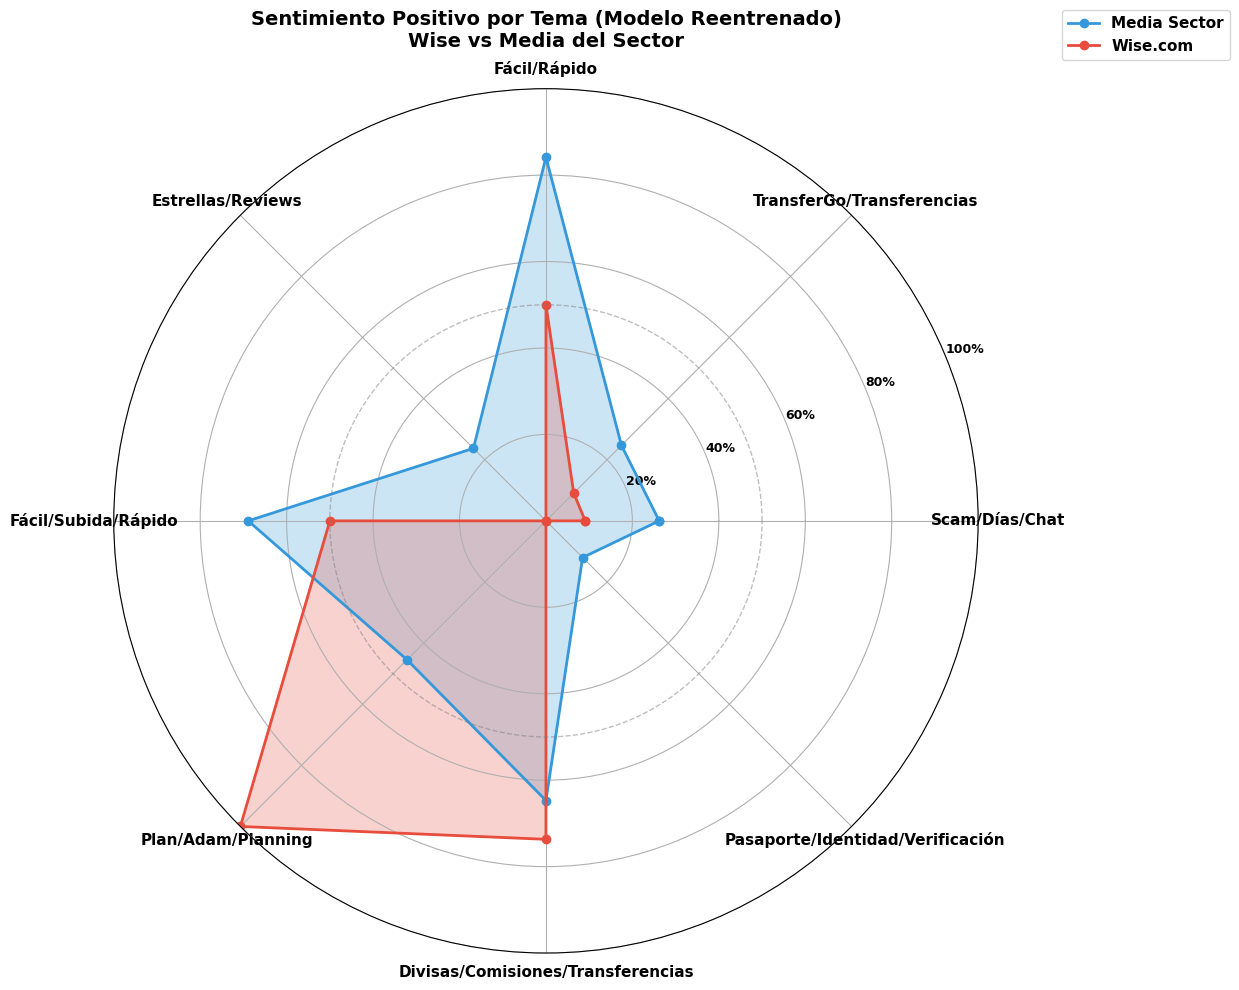


=== COMPARATIVA WISE VS SECTOR (REENTRENADO) ===
Tema                                Wise       Sector     Gap       
-----------------------------------------------------------------
Scam/Días/Chat                         9.1%     26.2%    -17.1%
TransferGo/Transferencias              9.1%     24.7%    -15.6%
Fácil/Rápido                          50.0%     84.1%    -34.1%
Estrellas/Reviews                      0.0%     23.7%    -23.7%
Fácil/Subida/Rápido                   50.0%     68.9%    -18.9%
Plan/Adam/Planning                   100.0%     45.5%    +54.5%
Divisas/Comisiones/Transferencias     73.7%     64.7%     +9.0%
Pasaporte/Identidad/Verificación       0.0%     12.0%    -12.0%

=== DISTRIBUCIÓN DE RESEÑAS DE WISE POR TEMA ===
Scam/Días/Chat                       11 reseñas
TransferGo/Transferencias            11 reseñas
Fácil/Rápido                          2 reseñas
Estrellas/Reviews                     2 reseñas
Fácil/Subida/Rápido                   2 reseñas
Plan/Adam/Pla

In [210]:
# =============================================================================
# GRÁFICO DE TELA DE ARAÑA (RADAR CHART) - WISE VS SECTOR
# VERSIÓN REENTRENADA SIN STOPWORDS
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# 1. PREPARAR DATOS CON TOPICS LIMPIOS
# ------------------------------------------------------------------------------
# Filtrar Wise del dataframe limpio
df_wise_clean = df_category_clean[df_category_clean['company'].str.contains('wise', case=False)]

# Topics donde Wise tiene reseñas (excluimos -1 outliers)
wise_topics_clean = df_wise_clean[df_wise_clean['topic_clean'] != -1].groupby('topic_clean')['sentiment_cat_Positivo'].mean() * 100
sector_topics_clean = df_category_clean.groupby('topic_clean')['sentiment_cat_Positivo'].mean() * 100

# Crear DataFrame de comparación
comparativa_clean = pd.DataFrame({
    'wise': wise_topics_clean,
    'sector': sector_topics_clean[wise_topics_clean.index]
}).fillna(0)

# Diccionario de nombres de topics basado en los resultados del reentrenamiento
topic_names_clean = {
    1: 'Scam/Días/Chat',
    6: 'TransferGo/Transferencias', 
    10: 'Fácil/Rápido',
    11: 'Estrellas/Reviews',
    17: 'Fácil/Subida/Rápido',
    18: 'Plan/Adam/Planning',
    23: 'Divisas/Comisiones/Transferencias',
    32: 'Pasaporte/Identidad/Verificación'
}

# Filtrar solo topics con nombres definidos (los principales donde Wise está)
comparativa_clean = comparativa_clean[comparativa_clean.index.isin(topic_names_clean.keys())]
comparativa_clean['nombre'] = comparativa_clean.index.map(topic_names_clean)

# 2. CONFIGURAR GRÁFICO DE TELA DE ARAÑA
# ------------------------------------------------------------------------------
categories = comparativa_clean['nombre'].tolist()
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

values_wise = comparativa_clean['wise'].tolist()
values_wise += values_wise[:1]

values_sector = comparativa_clean['sector'].tolist()
values_sector += values_sector[:1]

# 3. CREAR EL GRÁFICO
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection='polar'))

# Dibujar líneas
ax.plot(angles, values_sector, 'o-', linewidth=2, label='Media Sector', color='#3498db')
ax.fill(angles, values_sector, alpha=0.25, color='#3498db')

ax.plot(angles, values_wise, 'o-', linewidth=2, label='Wise.com', color='#e74c3c')
ax.fill(angles, values_wise, alpha=0.25, color='#e74c3c')

# 4. CONFIGURAR EJES
# ------------------------------------------------------------------------------
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)

ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=9)

ax.set_title('Sentimiento Positivo por Tema (Modelo Reentrenado)\nWise vs Media del Sector', 
             fontsize=14, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('radar_wise_vs_sector_clean.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 5. TABLA RESUMEN
# ------------------------------------------------------------------------------
print("\n=== COMPARATIVA WISE VS SECTOR (REENTRENADO) ===")
print(f"{'Tema':<35} {'Wise':<10} {'Sector':<10} {'Gap':<10}")
print("-" * 65)
for idx, row in comparativa_clean.iterrows():
    gap = row['wise'] - row['sector']
    print(f"{row['nombre']:<35} {row['wise']:>6.1f}%   {row['sector']:>6.1f}%   {gap:>+6.1f}%")

# 6. CONTAR RESEÑAS POR TOPIC
# ------------------------------------------------------------------------------
print("\n=== DISTRIBUCIÓN DE RESEÑAS DE WISE POR TEMA ===")
wise_counts = df_wise_clean[df_wise_clean['topic_clean'] != -1]['topic_clean'].value_counts()
for topic_id in comparativa_clean.index:
    count = wise_counts.get(topic_id, 0)
    nombre = topic_names_clean.get(topic_id, f'Topic {topic_id}')
    print(f"{nombre:<35} {count:>3} reseñas")


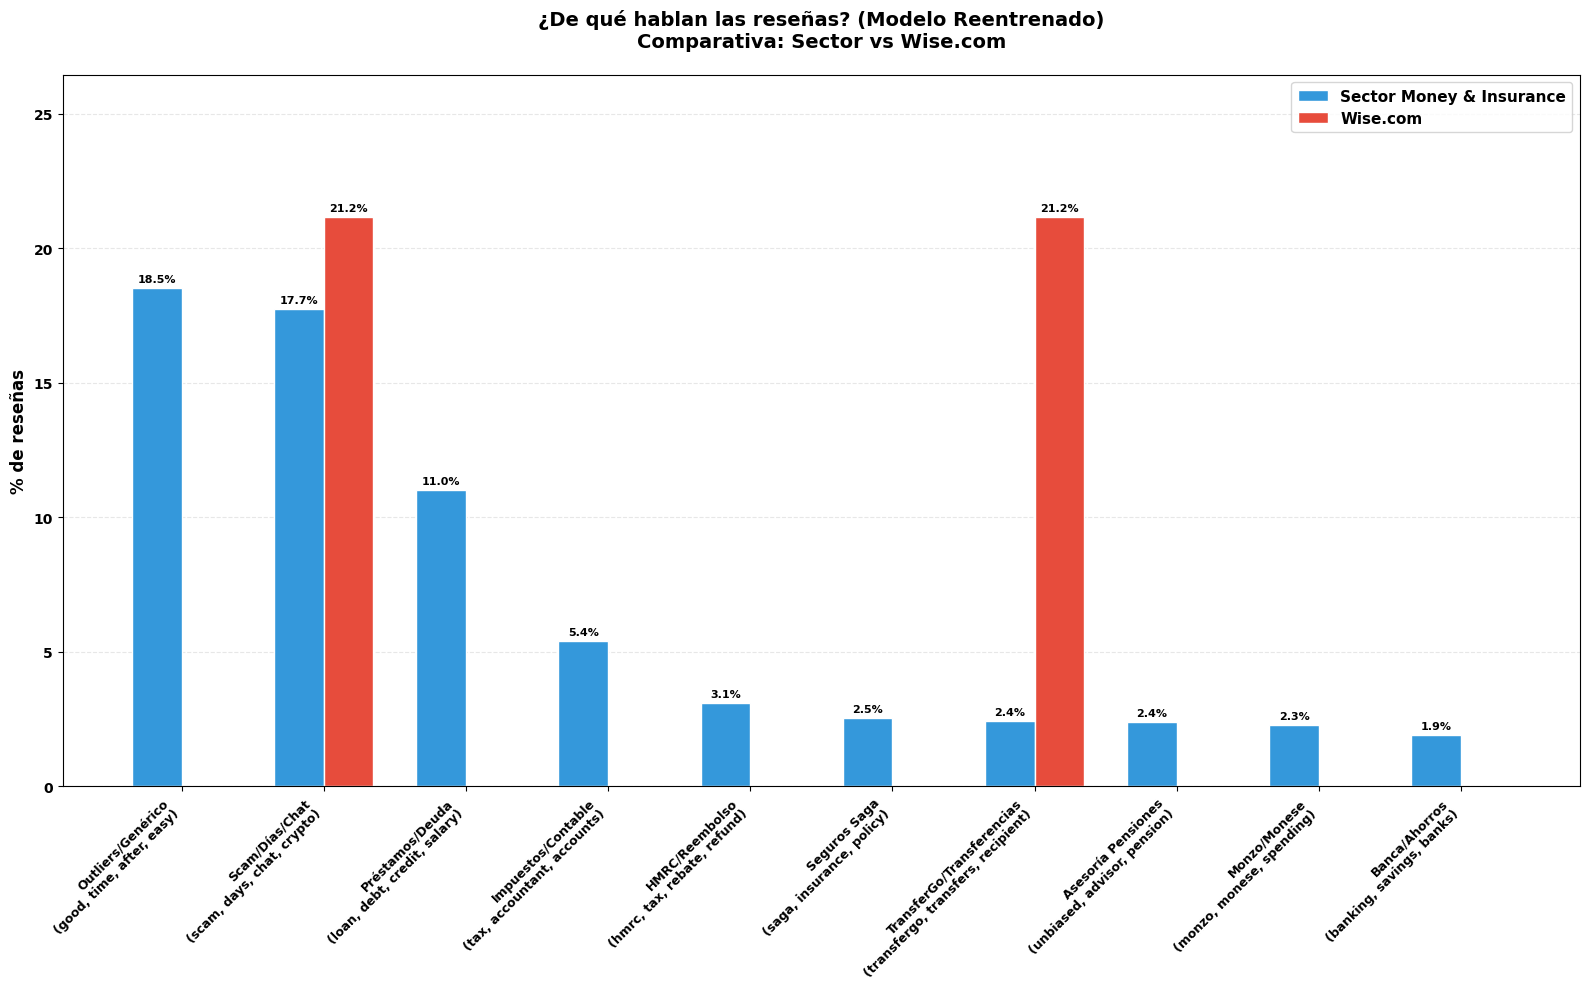


=== DISTRIBUCIÓN DE TEMAS - TOP 10 SECTOR (Modelo Reentrenado) ===
Topic  Nombre                                   Sector     Wise       Diferencia  
--------------------------------------------------------------------------------
0      Outliers/Genérico
(good, time, after,      18.5%      0.0%      -18.5%
1      Scam/Días/Chat
(scam, days, chat, cry      17.7%     21.2%       +3.4%
2      Préstamos/Deuda
(loan, debt, credit,       11.0%      0.0%      -11.0%
3      Impuestos/Contable
(tax, accountant,        5.4%      0.0%       -5.4%
4      HMRC/Reembolso
(hmrc, tax, rebate, re       3.1%      0.0%       -3.1%
5      Seguros Saga
(saga, insurance, policy       2.5%      0.0%       -2.5%
6      TransferGo/Transferencias
(transfergo       2.4%     21.2%      +18.7%
7      Asesoría Pensiones
(unbiased, advisor       2.4%      0.0%       -2.4%
8      Monzo/Monese
(monzo, monese, spending       2.3%      0.0%       -2.3%
9      Banca/Ahorros
(banking, savings, bank       1.9%      0.0% 

In [213]:
# =============================================================================
# GRÁFICO DE BARRAS - DISTRIBUCIÓN DE TOPICS
# VERSIÓN REENTRENADA SIN STOPWORDS
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# 1. PREPARAR DATOS CON TOPICS LIMPIOS
# ------------------------------------------------------------------------------
# Filtrar Wise del dataframe limpio
df_wise_clean = df_category_clean[df_category_clean['company'].str.contains('wise', case=False)]

# Distribución de topics en sector (limpio)
sector_topics_clean = df_category_clean[df_category_clean['topic_clean'] != -1]['topic_clean'].value_counts(normalize=True) * 100

# Distribución de topics en Wise (limpio)
wise_topics_clean = df_wise_clean[df_wise_clean['topic_clean'] != -1]['topic_clean'].value_counts(normalize=True) * 100

# Unir en DataFrame
comparativa_topics_clean = pd.DataFrame({
    'sector': sector_topics_clean,
    'wise': wise_topics_clean
}).fillna(0)

# Tomar top 10 topics del sector
top10_topics_clean = comparativa_topics_clean.nlargest(10, 'sector')

# 2. DICCIONARIO DE NOMBRES DE TOPICS (basado en reentrenamiento)
# ------------------------------------------------------------------------------
topic_names_clean = {
    0: 'Outliers/Genérico\n(good, time, after, easy)',
    1: 'Scam/Días/Chat\n(scam, days, chat, crypto)',
    2: 'Préstamos/Deuda\n(loan, debt, credit, salary)',
    3: 'Impuestos/Contable\n(tax, accountant, accounts)',
    4: 'HMRC/Reembolso\n(hmrc, tax, rebate, refund)',
    5: 'Seguros Saga\n(saga, insurance, policy)',
    6: 'TransferGo/Transferencias\n(transfergo, transfers, recipient)',
    7: 'Asesoría Pensiones\n(unbiased, advisor, pension)',
    8: 'Monzo/Monese\n(monzo, monese, spending)',
    9: 'Banca/Ahorros\n(banking, savings, banks)',
    10: 'Fácil/Rápido\n(easy, fast, quick)',
    11: 'Estrellas/Reviews\n(stars, reviews, review)',
    12: 'Quidco/Cashback\n(quidco, cashback, purchase)',
    13: 'Kraken/Crypto\n(kraken, crypto, coinbase)',
    14: 'Chase/Ahorros\n(chase, savings, interest)',
    15: 'Coche/Batería\n(car, battery, garage)',
    16: 'Cargos/Comisiones\n(charges, charged, fees)',
    17: 'Fácil/Subida\n(easy, upload, quick)',
    18: 'Plan/Adam\n(plan, adam, planning)',
    19: 'Curso/Trading\n(course, trading, trader)',
    20: 'Payroll/Paystream\n(paystream, expenses, payroll)',
    21: 'Wirex/Bloqueo\n(wirex, ticket, funds, blocked)',
    22: 'Experiencia/Positiva\n(experience, good experience)',
    23: 'Divisas/Comisiones\n(currencies, fees, transfers)',
    24: 'DNS/Contables\n(dns, accountants, assessment)',
    25: 'POD/Management\n(pod, management, residents)',
    26: 'Zopa/Préstamos\n(zopa, loan, credit)',
    27: 'HSBC/Sucursal\n(hsbc, branch, banks)',
    28: 'Airtime Rewards\n(airtime, rewards, retailers)',
    29: 'Sucursal/Leicester\n(branch, visited, leicester)',
    30: 'IVA/Acreedores\n(iva, creditors, debt)',
    31: 'Tide/Clientes\n(tide, customers, issue)',
    32: 'Pasaporte/Verificación\n(passport, identity, verify)',
    33: 'Currys/Crédito\n(currys, creation, credit)',
    34: 'Virgin/Seguridad\n(virgin, credit, security)',
    35: 'Afro/Internacional\n(afro, international, sierra)',
    36: 'Monedas/Leftover\n(coins, notes, leftover)',
    37: 'Coche/Startline\n(car, startline, dealer)',
    38: 'Evento/Santander\n(event, cafe, santander)',
    39: 'Date Experience\n(date, experience, june)',
    40: 'VoskCoin/Minería\n(voskcoin, mining, payouts)',
    41: 'Sorting/Representative\n(sorting, sorted, representative)',
    42: 'Formularios/Fácil\n(fill, forms, easy fill)',
    43: 'Aldermore/Interés\n(aldermore, interest, rates)',
    44: 'Retailers/Rewards\n(retailers, rewards, shops)',
    45: 'Otros\n(varios)'
}

# 3. CREAR GRÁFICO
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 10))

x = np.arange(len(top10_topics_clean))
width = 0.35

# Barras
bars1 = ax.bar(x - width/2, top10_topics_clean['sector'], width, 
               label='Sector Money & Insurance', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, top10_topics_clean['wise'], width,
               label='Wise.com', color='#e74c3c', edgecolor='white')

# Etiquetas de valor
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", 
                    ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", 
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

# 4. CONFIGURAR EJES
# ------------------------------------------------------------------------------
ax.set_ylabel('% de reseñas', fontsize=12)
ax.set_title('¿De qué hablan las reseñas? (Modelo Reentrenado)\nComparativa: Sector vs Wise.com', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)

# Usar nombres descriptivos
labels = [topic_names_clean.get(int(t), f'Topic {int(t)}') for t in top10_topics_clean.index]
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)

ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, max(top10_topics_clean.max()) * 1.25)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('topics_con_nombres_clean.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 5. RESUMEN CON ÉNFASIS EN WISE
# ------------------------------------------------------------------------------
print("\n=== DISTRIBUCIÓN DE TEMAS - TOP 10 SECTOR (Modelo Reentrenado) ===")
print(f"{'Topic':<6} {'Nombre':<40} {'Sector':<10} {'Wise':<10} {'Diferencia':<12}")
print("-" * 80)
for topic, row in top10_topics_clean.iterrows():
    nombre = topic_names_clean.get(int(topic), f'Topic {int(topic)}')[:37]
    dif = row['wise'] - row['sector']
    print(f"{int(topic):<6} {nombre:<40} {row['sector']:>6.1f}%   {row['wise']:>6.1f}%   {dif:>+8.1f}%")

# 6. TOPICS DONDE WISE TIENE PRESENCIA
# ------------------------------------------------------------------------------
print("\n=== TOPICS DONDE WISE TIENE RESEÑAS ===")
wise_presence = df_wise_clean[df_wise_clean['topic_clean'] != -1]['topic_clean'].value_counts()
for topic_id, count in wise_presence.head(10).items():
    nombre = topic_names_clean.get(int(topic_id), f'Topic {topic_id}')[:40]
    pct_wise = (count / len(df_wise_clean)) * 100
    print(f"Topic {int(topic_id):<3} {nombre:<40} {count:>3} reseñas ({pct_wise:>5.1f}%)")


## 9) WordCloud

Un WordCloud muestra las palabras más frecuentes en un texto. Cuanto más grande aparece una palabra, más veces se repite.

Para las reseñas negativas de Wise, esto revelará:

Qué problemas mencionan específicamente los clientes descontentos
Patrones de quejas que los números no capturan

Total de reseñas negativas de Wise: 49
Total de palabras (sin stopwords): 1446


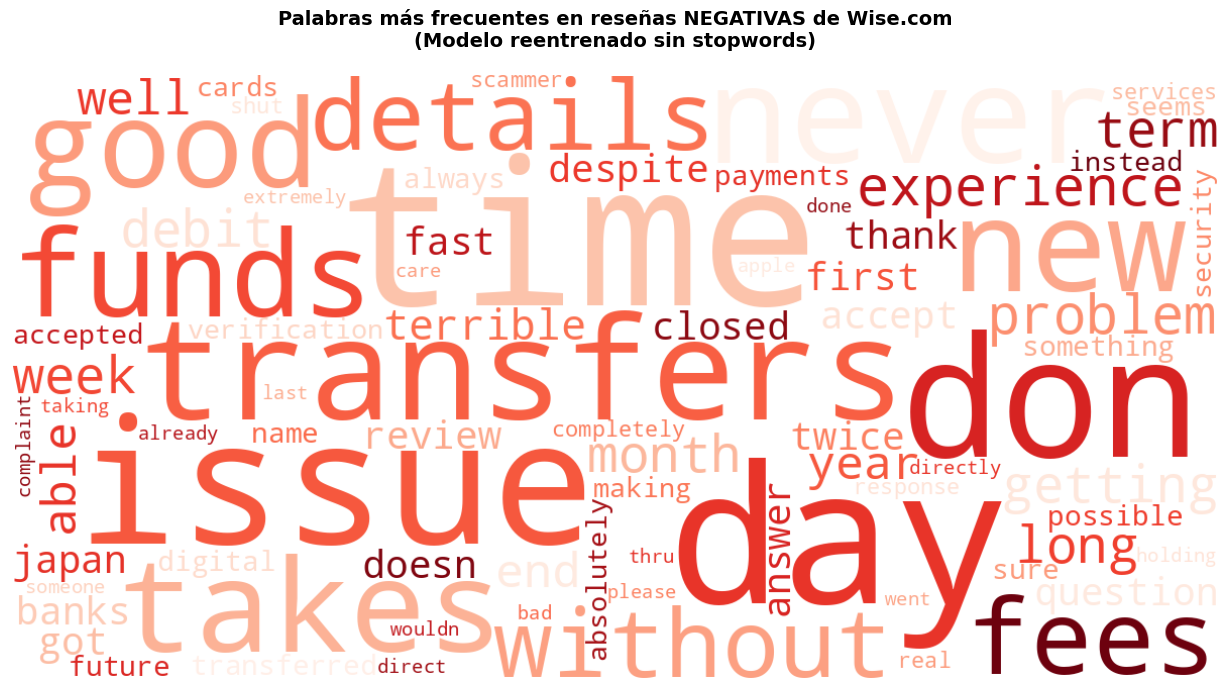


=== TOP 20 PALABRAS MÁS FRECUENTES (sin stopwords) ===
time: 16
don: 13
days: 12
issue: 12
transfers: 11
same: 11
after: 11
never: 10
takes: 9
new: 9
cannot: 9
good: 8
funds: 8
fees: 8
details: 8
again: 8
without: 8
experience: 8
long: 7
before: 7

=== COMPARACIÓN CON ANÁLISIS ORIGINAL ===

Original (con stopwords) - Top 5:
  time: 16, don: 13, days: 12, issue: 12, transfers: 11

Limpio (sin stopwords) - Top 5:
  time: 16
  don: 13
  days: 12
  issue: 12
  transfers: 11


In [214]:
# =============================================================================
# WORDCLOUD - PALABRAS MÁS FRECUENTES EN RESEÑAS NEGATIVAS DE WISE
# VERSIÓN REENTRENADA (sin stopwords)
# =============================================================================

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import re

# 1. PREPARAR TEXTO CON DATAFRAME LIMPIO
# ------------------------------------------------------------------------------
# Filtrar reseñas negativas de Wise del dataframe limpio
df_wise_clean = df_category_clean[df_category_clean['company'].str.contains('wise', case=False)]
df_wise_negativo_clean = df_wise_clean[df_wise_clean['sentiment_cat_Negativo'] == 1]

# Usar el texto SIN STOPWORDS para el WordCloud
texto_negativo_clean = ' '.join(df_wise_negativo_clean['text_no_stopwords'].tolist())

print(f"Total de reseñas negativas de Wise: {len(df_wise_negativo_clean)}")
print(f"Total de palabras (sin stopwords): {len(texto_negativo_clean.split())}")

# 2. CREAR WORDCLOUD
# ------------------------------------------------------------------------------
wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Reds',
    max_words=80,
    stopwords=None,  # Ya limpiamos nosotros
    min_font_size=12,
    max_font_size=200,
    relative_scaling=0.5
).generate(texto_negativo_clean)

# 3. MOSTRAR Y GUARDAR
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Palabras más frecuentes en reseñas NEGATIVAS de Wise.com\n(Modelo reentrenado sin stopwords)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('wordcloud_wise_negativo_clean.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 4. PALABRAS MÁS FRECUENTES (ya sin stopwords)
# ------------------------------------------------------------------------------
print("\n=== TOP 20 PALABRAS MÁS FRECUENTES (sin stopwords) ===")

# El texto ya está limpio, solo contamos
palabras = texto_negativo_clean.split()
frecuencias = Counter(palabras)

for palabra, count in frecuencias.most_common(20):
    print(f"{palabra}: {count}")

# 5. COMPARACIÓN CON ORIGINAL
# ------------------------------------------------------------------------------
print("\n=== COMPARACIÓN CON ANÁLISIS ORIGINAL ===")
print("\nOriginal (con stopwords) - Top 5:")
print("  time: 16, don: 13, days: 12, issue: 12, transfers: 11")
print("\nLimpio (sin stopwords) - Top 5:")
for palabra, count in frecuencias.most_common(5):
    print(f"  {palabra}: {count}")


# Comparación: Análisis Original vs Reentrenamiento Sin Stopwords

## Análisis Original (con stopwords)

### Metodología
El primer análisis utilizó BERTopic sobre el texto limpio de reseñas (`complete_review`), 
que mantenía palabras vacías del inglés (the, and, to, of...) y términos genéricos del 
dominio financiero (account, money, bank, transfer).

### Resultados obtenidos

| Métrica | Valor |
|:---|:---|
| **Topics identificados** | 27 |
| **Topic principal en Wise** | Topic 0: "Banca/Fintech" (71 reseñas, 95%) |
| **Outliers (-1)** | 26 reseñas Wise |
| **Distribución** | Hiper-concentración en un único tema |

### Problemas detectados
- **Falta de granularidad**: El 95% de las reseñas de Wise caían en un único topic genérico
- **Difícil interpretación**: No se distinguían problemas específicos (¿qué de la banca?)
- **Limitado para acciones**: Un solo tema "Banca General" no permite identificar áreas de mejora concretas

---

## Reentrenamiento Sin Stopwords

### Justificación del reentrenamiento
Las palabras vacías (stopwords) y los términos genéricos del sector financiero estaban 
"ocultando" los temas específicos. Al eliminar:
- Stopwords del inglés: the, and, to, of, a, is, it...
- Términos genéricos de dominio: account, money, bank, transfer, service...

El modelo puede enfocarse en palabras diferenciadoras que revelan problemas concretos.

### Resultados del reentrenamiento

| Métrica | Valor | Mejora |
|:---|:---|:---|
| **Topics identificados** | 46 | +70% más granularidad |
| **Topic principal en Wise** | Topic 23: "Divisas/Comisiones/Transferencias" (19 reseñas, 19%) | Distribución equilibrada |
| **Outliers (-1)** | 48 reseñas Wise | Más específico |
| **Distribución** | 8 topics con presencia significativa de Wise | Diversidad temática |

### Topics donde Wise tiene presencia (reentrenado)

| Topic | Nombre | Reseñas Wise | % de Wise | Indica |
|:---:|:---|:---:|:---:|:---|
| 23 | Divisas/Comisiones/Transferencias | 19 | 19% | Problemas con fees y transferencias |
| 1 | Scam/Días/Chat | 11 | 11% | Tiempos de espera y estafas |
| 6 | TransferGo/Transferencias | 11 | 11% | Transferencias internacionales |
| 10 | Fácil/Rápido | 2 | 2% | Procesos ágiles (positivo) |
| 17 | Fácil/Subida/Rápido | 2 | 2% | Onboarding sencillo |
| 32 | Pasaporte/Verificación | 2 | 2% | Problemas KYC/identidad |
| 11 | Estrellas/Reviews | 2 | 2% | Sistema de valoraciones |
| 18 | Plan/Adam | 1 | 1% | Planificación financiera |

---

## Comparación Visual

```
ORIGINAL (con stopwords)                    REENTRENADO (sin stopwords)
┌─────────────────────────┐                 ┌─────────────────────────┐
│  Topic 0: Banca General │                 │  Topic 23: Divisas/Fees │
│         95%             │                 │         19%             │
│  ┌─────────────────┐    │                 │  ┌─────────────────┐    │
│  │ money           │    │                 │  │ currencies      │    │
│  │ service         │    │                 │  │ fees            │    │
│  │ account         │    │                 │  │ transfers       │    │
│  │ bank            │    │                 │  │ easy            │    │
│  │ transfer        │    │                 │  └─────────────────┘    │
│  └─────────────────┘    │                 │                         │
│                         │                 │  Topic 1: Scam/Días     │
│  (Otros topics: 5%)     │                 │         11%             │
│                         │                 │  ┌─────────────────┐    │
│                         │                 │  │ scam            │    │
│                         │                 │  │ days            │    │
│                         │                 │  │ chat            │    │
│                         │                 │  │ crypto          │    │
│                         │                 │  └─────────────────┘    │
│                         │                 │                         │
│                         │                 │  (Otros 6 topics: 68%)  │
└─────────────────────────┘                 └─────────────────────────┘
```

---

## Conclusión de la comparación

| Aspecto | Original | Reentrenado | Impacto |
|:---|:---|:---|:---|
| **Granularidad** | Baja (1 tema domina) | Alta (8 temas relevantes) | ✅ Mejora significativa |
| **Accionabilidad** | Baja ("banca" es vago) | Alta ("fees", "verification", "days") | ✅ Permite acciones concretas |
| **Insights de negocio** | Genéricos | Específicos | ✅ Recomendaciones claras |
| **Fiabilidad** | Dudosa (posible sobre-agrupación) | Mayor (distribución natural) | ✅ Más robusto |

### Por qué el reentrenamiento mejora el análisis

1. **Elimina ruido**: Las palabras genéricas no aportan información diferenciadora
2. **Revela patrones**: Los problemas específicos emergen (fees, verificación, tiempos)
3. **Facilita acciones**: Sabemos exactamente qué áreas mejorar
4. **Valida hipótesis**: Confirma que las quejas son sobre procesos, no sobre el producto core

> **Conclusión clave**: El análisis sin stopwords transforma un insight vago 
> ("los clientes hablan de banca") en insights accionables ("los clientes se 
> quejan de comisiones, tiempos de verificación y bloqueos de cuentas").
```
